# H1/H2 측정타당성 Validation Gate

이 노트북은 기존 `h1_h2.ipynb` 분석을 새로 매핑하거나 덮어쓰지 않는다. 목적은 기존에 구성된
`crosswalk`, `mapping_type`, `mapping_confidence`, `valid_for_primary_model`,
`selectivity_pct_2024`, `score_comparability_tier`, `department_admission_feature`를 감사하고,
검증된 표본만 별도로 재구성하는 것이다.

기본 실행 모드는 `prepare_review`다. 이 모드에서는 자동검증, 수동검토 큐 생성, Gate 판정까지만 수행한다.
사람이 `06_metric_definition_manual_decisions.csv`와 `11_alias_manual_decisions.csv`를 채운 뒤에만
`RUN_MODE = "apply_review"`로 승인 결과를 반영한다.


In [1]:
# 01_config_and_paths
from __future__ import annotations

import ast
import hashlib
import json
import math
import os
import re
import time
import warnings
from datetime import datetime, timezone
from difflib import SequenceMatcher
from pathlib import Path

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_DIR = Path("/home/sieg/projects-wsl/SBS_dataScience")
BASE_DIR = PROJECT_DIR / "workbook/p2/p2_2"
VAL_OUTPUT_DIR = BASE_DIR / "val_outputs"
VAL_FIGURE_DIR = VAL_OUTPUT_DIR / "figures"
VAL_SOURCE_CACHE_DIR = VAL_OUTPUT_DIR / "source_cache"

VAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
VAL_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
VAL_SOURCE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

RUN_MODE = "prepare_review"  # "prepare_review" or "apply_review"
ADMISSION_YEAR = 2024
GRADE_YEAR = 2024
VALIDATION_RUN_ID = f"VAL_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

if RUN_MODE not in {"prepare_review", "apply_review"}:
    raise ValueError("RUN_MODE must be 'prepare_review' or 'apply_review'")

font_candidates = ["NanumGothic", "Noto Sans CJK KR", "Malgun Gothic", "DejaVu Sans"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in font_candidates:
    if font_name in available_fonts:
        mpl.rcParams["font.family"] = font_name
        break
mpl.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=mpl.rcParams["font.family"])

TRACE_COLS = [
    "validation_run_id",
    "source_id",
    "raw_row_id",
    "univ_id",
    "univ_name_std",
    "campus_id",
    "source_url",
    "source_file",
    "retrieved_at",
    "content_sha256",
    "parser_version",
    "review_status",
    "reviewer",
    "reviewed_at",
    "validation_note",
]

REVIEW_STATUS_ALLOWED = ["auto_pass", "manual_pass", "manual_reject", "unresolved", "not_required"]


def normalize_text(value: object) -> str:
    if pd.isna(value):
        return ""
    return re.sub(r"\s+", " ", str(value)).strip()


def coerce_numeric(series: pd.Series) -> pd.Series:
    cleaned = (
        series.astype("string")
        .str.replace(",", "", regex=False)
        .str.extract(r"([-+]?\d+(?:\.\d+)?)", expand=False)
    )
    return pd.to_numeric(cleaned, errors="coerce")


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as fh:
        for chunk in iter(lambda: fh.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def read_table(path: Path, nrows: int | None = None) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".parquet":
        df = pd.read_parquet(path)
        if nrows is not None:
            df = df.head(nrows)
    else:
        df = pd.read_csv(path, nrows=nrows, low_memory=False)
    return df.convert_dtypes()


def table_shape(path: Path) -> tuple[int | None, int | None, str | None]:
    try:
        df = read_table(path)
        return int(len(df)), int(df.shape[1]), None
    except Exception as exc:
        return None, None, repr(exc)


def write_csv(df: pd.DataFrame, filename: str, index: bool = False) -> Path:
    path = VAL_OUTPUT_DIR / filename
    out = df.copy()
    out.to_csv(path, index=index, encoding="utf-8-sig")
    return path


def write_decision_template_if_missing(df: pd.DataFrame, filename: str) -> Path:
    path = VAL_OUTPUT_DIR / filename
    if path.exists():
        return path
    df.to_csv(path, index=False, encoding="utf-8-sig")
    return path


def add_trace(
    df: pd.DataFrame,
    review_status: str = "unresolved",
    validation_note: str = "",
) -> pd.DataFrame:
    out = df.copy()
    if "validation_run_id" not in out.columns:
        out.insert(0, "validation_run_id", VALIDATION_RUN_ID)
    for col in TRACE_COLS:
        if col not in out.columns:
            out[col] = pd.NA
    out["review_status"] = out["review_status"].fillna(review_status)
    out["validation_note"] = out["validation_note"].fillna(validation_note)
    return out


def bool_series(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series.fillna(False)
    return series.astype("string").str.lower().isin(["true", "1", "yes", "y", "t"])


def bool_scalar(value: object) -> bool:
    if pd.isna(value):
        return False
    if isinstance(value, str):
        return value.strip().lower() in {"true", "1", "yes", "y", "t"}
    return bool(value)


def safe_divide(num: pd.Series, den: pd.Series) -> pd.Series:
    num = pd.to_numeric(num, errors="coerce").astype("float64")
    den = pd.to_numeric(den, errors="coerce").astype("float64")
    return np.where(den.gt(0).fillna(False), num / den, np.nan)


def spearman_safe(df: pd.DataFrame, x: str, y: str) -> tuple[float, float, int]:
    sub = df[[x, y]].dropna()
    if len(sub) < 3 or sub[x].nunique() < 2 or sub[y].nunique() < 2:
        return np.nan, np.nan, int(len(sub))
    rho, p = stats.spearmanr(sub[x], sub[y])
    return float(rho), float(p), int(len(sub))


def kendall_safe(df: pd.DataFrame, x: str, y: str) -> tuple[float, float, int]:
    sub = df[[x, y]].dropna()
    if len(sub) < 3 or sub[x].nunique() < 2 or sub[y].nunique() < 2:
        return np.nan, np.nan, int(len(sub))
    tau, p = stats.kendalltau(sub[x], sub[y])
    return float(tau), float(p), int(len(sub))


audit_log: list[dict[str, object]] = []


def log_event(gate: str, event: str, status: str, rows: int | None = None, note: str = "") -> None:
    audit_log.append(
        {
            "validation_run_id": VALIDATION_RUN_ID,
            "timestamp": datetime.now().isoformat(timespec="seconds"),
            "gate": gate,
            "event": event,
            "status": status,
            "rows": rows,
            "note": note,
        }
    )


display(
    Markdown(
        f'''
**Validation run**: `{VALIDATION_RUN_ID}`  
**RUN_MODE**: `{RUN_MODE}`  
**BASE_DIR**: `{BASE_DIR}`  
**VAL_OUTPUT_DIR**: `{VAL_OUTPUT_DIR}`
'''
    )
)



**Validation run**: `VAL_20260710_162327`  
**RUN_MODE**: `prepare_review`  
**BASE_DIR**: `/home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_2`  
**VAL_OUTPUT_DIR**: `/home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_2/val_outputs`


In [2]:
# 02_input_inventory
TARGET_FILENAMES = [
    "02_admission_result_raw_2024.csv",
    "02_admission_result_raw_2024.parquet",
    "01_crawl_source_registry.csv",
    "00_crawl_seed_university_2024.csv",
    "recruitment_grade_department_crosswalk_2024.csv",
    "department_admission_feature_2024.csv",
    "department_h1_h2_actual_admission_2024.csv",
    "department_actual_selectivity_residuals_2024.csv",
    "university_analysis_table_2024.csv",
    "P2_학과별_A비율_대학아님.csv",
    "P2__전체대학학점비율.csv",
    "department_grade_target_2024_regular_term_mean.csv",
]

PREFERRED_RELATIVE_PATHS = {
    "02_admission_result_raw_2024.csv": "data/crawl_2024_admission/02_admission_result_raw_2024.csv",
    "02_admission_result_raw_2024.parquet": "data/crawl_2024_admission/02_admission_result_raw_2024.parquet",
    "01_crawl_source_registry.csv": "data/crawl_2024_admission/01_crawl_source_registry.csv",
    "00_crawl_seed_university_2024.csv": "data/crawl_2024_admission/00_crawl_seed_university_2024.csv",
    "recruitment_grade_department_crosswalk_2024.csv": "data/actual_admission_2024/recruitment_grade_department_crosswalk_2024.csv",
    "department_admission_feature_2024.csv": "data/actual_admission_2024/department_admission_feature_2024.csv",
    "department_h1_h2_actual_admission_2024.csv": "data/actual_admission_2024/department_h1_h2_actual_admission_2024.csv",
    "department_actual_selectivity_residuals_2024.csv": "data/actual_admission_2024/department_actual_selectivity_residuals_2024.csv",
    "university_analysis_table_2024.csv": "data/analysis_csv/university_analysis_table_2024.csv",
    "P2_학과별_A비율_대학아님.csv": "P2_학과별_A비율_대학아님.csv",
    "P2__전체대학학점비율.csv": "P2__전체대학학점비율.csv",
    "department_grade_target_2024_regular_term_mean.csv": "data/analysis_csv/department_grade_target_2024_regular_term_mean.csv",
}

SKIP_PARTS = {".git", ".venv", "node_modules", "__pycache__", ".ipynb_checkpoints"}


def discover_candidates(filename: str) -> list[Path]:
    exact = [
        p
        for p in PROJECT_DIR.rglob(filename)
        if not any(part in SKIP_PARTS for part in p.parts)
    ]
    if exact:
        return sorted(exact)
    stem = Path(filename).stem
    suffix = Path(filename).suffix
    loose = [
        p
        for p in PROJECT_DIR.rglob(f"*{stem}*{suffix}")
        if not any(part in SKIP_PARTS for part in p.parts)
    ]
    return sorted(loose)


inventory_rows: list[dict[str, object]] = []
selected_paths: dict[str, Path] = {}

for filename in TARGET_FILENAMES:
    candidates = discover_candidates(filename)
    preferred = BASE_DIR / PREFERRED_RELATIVE_PATHS.get(filename, "")
    selected_path = None
    selected_reason = "not_found"
    if preferred.exists() and preferred in candidates:
        selected_path = preferred
        selected_reason = "preferred_canonical_path"
    elif len(candidates) == 1:
        selected_path = candidates[0]
        selected_reason = "only_exact_or_loose_candidate"
    elif len(candidates) > 1:
        selected_reason = "multiple_candidates_no_implicit_latest_selection"

    if selected_path is not None:
        selected_paths[filename] = selected_path

    for i, path in enumerate(candidates):
        row_count, col_count, load_error = table_shape(path)
        stat = path.stat()
        inventory_rows.append(
            {
                "validation_run_id": VALIDATION_RUN_ID,
                "target_filename": filename,
                "candidate_index": i,
                "absolute_path": str(path.resolve()),
                "relative_to_project": str(path.relative_to(PROJECT_DIR)),
                "selected": path == selected_path,
                "selected_reason": selected_reason if path == selected_path else "candidate_not_selected",
                "modified_at": datetime.fromtimestamp(stat.st_mtime).isoformat(timespec="seconds"),
                "file_size_bytes": stat.st_size,
                "sha256": sha256_file(path),
                "row_count": row_count,
                "column_count": col_count,
                "load_error": load_error,
            }
        )
    if not candidates:
        inventory_rows.append(
            {
                "validation_run_id": VALIDATION_RUN_ID,
                "target_filename": filename,
                "candidate_index": pd.NA,
                "absolute_path": pd.NA,
                "relative_to_project": pd.NA,
                "selected": False,
                "selected_reason": "not_found",
                "modified_at": pd.NA,
                "file_size_bytes": pd.NA,
                "sha256": pd.NA,
                "row_count": pd.NA,
                "column_count": pd.NA,
                "load_error": "file_not_found",
            }
        )

input_inventory = pd.DataFrame(inventory_rows).convert_dtypes()
write_csv(input_inventory, "01_input_file_inventory.csv")

required_names = [
    "02_admission_result_raw_2024.csv",
    "01_crawl_source_registry.csv",
    "recruitment_grade_department_crosswalk_2024.csv",
    "department_h1_h2_actual_admission_2024.csv",
    "P2_학과별_A비율_대학아님.csv",
    "P2__전체대학학점비율.csv",
]
missing_required = [name for name in required_names if name not in selected_paths]
log_event("Gate0", "input_inventory", "PASS" if not missing_required else "FAIL", len(input_inventory), f"missing={missing_required}")

display(input_inventory.query("selected == True")[["target_filename", "relative_to_project", "row_count", "column_count", "selected_reason"]])


,target_filename,relative_to_project,row_count,column_count,selected_reason
0,02_admission_result_raw_2024.csv,workbook/p2/p2_2/data/crawl_2024_admission/02_...,3096,18,preferred_canonical_path
1,02_admission_result_raw_2024.parquet,workbook/p2/p2_2/data/crawl_2024_admission/02_...,3096,18,preferred_canonical_path
2,01_crawl_source_registry.csv,workbook/p2/p2_2/data/crawl_2024_admission/01_...,51,18,preferred_canonical_path
3,00_crawl_seed_university_2024.csv,workbook/p2/p2_2/data/crawl_2024_admission/00_...,52,12,preferred_canonical_path
4,recruitment_grade_department_crosswalk_2024.csv,workbook/p2/p2_2/data/actual_admission_2024/re...,2026,32,preferred_canonical_path
5,department_admission_feature_2024.csv,workbook/p2/p2_2/data/actual_admission_2024/de...,1216,23,preferred_canonical_path
6,department_h1_h2_actual_admission_2024.csv,workbook/p2/p2_2/data/actual_admission_2024/de...,1216,62,preferred_canonical_path
7,department_actual_selectivity_residuals_2024.csv,workbook/p2/p2_2/data/actual_admission_2024/de...,1186,64,preferred_canonical_path
8,university_analysis_table_2024.csv,workbook/p2/p2_2/data/analysis_csv/university_...,47,63,preferred_canonical_path
9,P2_학과별_A비율_대학아님.csv,workbook/p2/p2_2/P2_학과별_A비율_대학아님.csv,4644,7,preferred_canonical_path


In [3]:
# 03_load_existing_pipeline
def load_selected(filename: str, required: bool = True) -> pd.DataFrame:
    path = selected_paths.get(filename)
    if path is None:
        if required:
            raise FileNotFoundError(f"No selected path for {filename}")
        return pd.DataFrame()
    df = read_table(path)
    df.attrs["source_path"] = str(path)
    return df


raw_admission = load_selected("02_admission_result_raw_2024.csv")
source_registry = load_selected("01_crawl_source_registry.csv")
seed_university = load_selected("00_crawl_seed_university_2024.csv", required=False)
crosswalk = load_selected("recruitment_grade_department_crosswalk_2024.csv")
department_admission_feature = load_selected("department_admission_feature_2024.csv", required=False)
department_model = load_selected("department_h1_h2_actual_admission_2024.csv")
department_residuals = load_selected("department_actual_selectivity_residuals_2024.csv", required=False)
university_analysis = load_selected("university_analysis_table_2024.csv", required=False)
dept_reference = load_selected("P2_학과별_A비율_대학아님.csv")
grade_raw = load_selected("P2__전체대학학점비율.csv")
department_grade_target = load_selected("department_grade_target_2024_regular_term_mean.csv", required=False)

loaded_tables = {
    "raw_admission": raw_admission,
    "source_registry": source_registry,
    "seed_university": seed_university,
    "crosswalk": crosswalk,
    "department_admission_feature": department_admission_feature,
    "department_model": department_model,
    "department_residuals": department_residuals,
    "university_analysis": university_analysis,
    "dept_reference": dept_reference,
    "grade_raw": grade_raw,
    "department_grade_target": department_grade_target,
}

load_summary = pd.DataFrame(
    [
        {
            "validation_run_id": VALIDATION_RUN_ID,
            "table_name": name,
            "rows": len(df),
            "columns": df.shape[1],
            "source_path": df.attrs.get("source_path", ""),
            "loaded": not df.empty,
        }
        for name, df in loaded_tables.items()
    ]
).convert_dtypes()

core_loaded = all(len(loaded_tables[name]) > 0 for name in ["raw_admission", "source_registry", "crosswalk", "department_model", "grade_raw"])
log_event("Gate0", "load_existing_pipeline", "PASS" if core_loaded else "FAIL", int(load_summary["loaded"].sum()))

display(load_summary)


,validation_run_id,table_name,rows,columns,source_path,loaded
0,VAL_20260710_162327,raw_admission,3096,18,/home/sieg/projects-wsl/SBS_dataScience/workbo...,True
1,VAL_20260710_162327,source_registry,51,18,/home/sieg/projects-wsl/SBS_dataScience/workbo...,True
2,VAL_20260710_162327,seed_university,52,12,/home/sieg/projects-wsl/SBS_dataScience/workbo...,True
3,VAL_20260710_162327,crosswalk,2026,32,/home/sieg/projects-wsl/SBS_dataScience/workbo...,True
4,VAL_20260710_162327,department_admission_feature,1216,23,/home/sieg/projects-wsl/SBS_dataScience/workbo...,True
5,VAL_20260710_162327,department_model,1216,62,/home/sieg/projects-wsl/SBS_dataScience/workbo...,True
6,VAL_20260710_162327,department_residuals,1186,64,/home/sieg/projects-wsl/SBS_dataScience/workbo...,True
7,VAL_20260710_162327,university_analysis,47,63,/home/sieg/projects-wsl/SBS_dataScience/workbo...,True
8,VAL_20260710_162327,dept_reference,4644,7,/home/sieg/projects-wsl/SBS_dataScience/workbo...,True
9,VAL_20260710_162327,grade_raw,31743,53,/home/sieg/projects-wsl/SBS_dataScience/workbo...,True


In [4]:
# 04_freeze_existing_baseline
baseline_rows: list[dict[str, object]] = []

for table_name, df in loaded_tables.items():
    if df.empty:
        continue
    row = {
        "validation_run_id": VALIDATION_RUN_ID,
        "baseline_type": "table_shape",
        "table_name": table_name,
        "rows": len(df),
        "university_count": df["univ_name_std"].nunique() if "univ_name_std" in df.columns else pd.NA,
        "department_count": df["dept_canonical_id"].nunique() if "dept_canonical_id" in df.columns else (
            df["dept_name_std"].nunique() if "dept_name_std" in df.columns else pd.NA
        ),
        "metric": "row_count",
        "value": len(df),
        "note": "existing pipeline frozen, no overwrite",
    }
    baseline_rows.append(row)

summary_files = [
    ("existing_h1_actual", BASE_DIR / "data/actual_admission_2024/actual_admission_h1_result_summary_2024.csv"),
    ("existing_h2_actual", BASE_DIR / "data/actual_admission_2024/actual_admission_h2_department_result_summary_2024.csv"),
    ("existing_h3_actual", BASE_DIR / "data/actual_admission_2024/actual_admission_h3_result_summary_2024.csv"),
    ("existing_h1_rank_baseline", BASE_DIR / "data/analysis_csv/h1_result_summary_2024.csv"),
    ("existing_h2_rank_baseline", BASE_DIR / "data/analysis_csv/h2_result_summary_2024.csv"),
    ("existing_h6_proxy", BASE_DIR / "data/actual_admission_2024/actual_admission_h3_result_summary_2024.csv"),
]

for label, path in summary_files:
    if not path.exists():
        baseline_rows.append(
            {
                "validation_run_id": VALIDATION_RUN_ID,
                "baseline_type": "summary_file_missing",
                "table_name": label,
                "rows": 0,
                "university_count": pd.NA,
                "department_count": pd.NA,
                "metric": "file_missing",
                "value": pd.NA,
                "note": str(path),
            }
        )
        continue
    try:
        summary_df = read_table(path)
        for _, rec in summary_df.head(200).iterrows():
            metric_name = rec.get("metric", rec.get("analysis", rec.get("test", "summary_row")))
            value = rec.get("value", rec.get("estimate", rec.get("coefficient", pd.NA)))
            baseline_rows.append(
                {
                    "validation_run_id": VALIDATION_RUN_ID,
                    "baseline_type": "existing_result_summary",
                    "table_name": label,
                    "rows": len(summary_df),
                    "university_count": pd.NA,
                    "department_count": pd.NA,
                    "metric": metric_name,
                    "value": value,
                    "note": json.dumps({k: str(v) for k, v in rec.to_dict().items()}, ensure_ascii=False)[:1000],
                }
            )
    except Exception as exc:
        baseline_rows.append(
            {
                "validation_run_id": VALIDATION_RUN_ID,
                "baseline_type": "summary_file_load_error",
                "table_name": label,
                "rows": pd.NA,
                "university_count": pd.NA,
                "department_count": pd.NA,
                "metric": "load_error",
                "value": pd.NA,
                "note": repr(exc),
            }
        )

existing_pipeline_baseline = pd.DataFrame(baseline_rows).convert_dtypes()
write_csv(existing_pipeline_baseline, "02_existing_pipeline_baseline.csv")

dist_frames = []
if not crosswalk.empty:
    cols = [c for c in ["score_comparability_tier", "mapping_type", "valid_for_primary_model"] if c in crosswalk.columns]
    dist = crosswalk.groupby(cols, dropna=False).size().reset_index(name="rows") if cols else pd.DataFrame()
    dist["source_table"] = "crosswalk"
    dist_frames.append(dist)
if not department_model.empty:
    cols = [c for c in ["score_comparability_tier", "mapping_type", "primary_sample_flag", "analysis_sample_tier_ab_flag"] if c in department_model.columns]
    dist = department_model.groupby(cols, dropna=False).size().reset_index(name="rows") if cols else pd.DataFrame()
    dist["source_table"] = "department_model"
    dist_frames.append(dist)

existing_tier_mapping_distribution = pd.concat(dist_frames, ignore_index=True, sort=False).convert_dtypes() if dist_frames else pd.DataFrame()
existing_tier_mapping_distribution.insert(0, "validation_run_id", VALIDATION_RUN_ID)
write_csv(existing_tier_mapping_distribution, "03_existing_tier_mapping_distribution.csv")

gate0_ready = core_loaded and not existing_tier_mapping_distribution.empty
log_event("Gate0", "freeze_existing_baseline", "PASS" if gate0_ready else "FAIL", len(existing_pipeline_baseline))

display(existing_tier_mapping_distribution.head(20))


,validation_run_id,score_comparability_tier,mapping_type,valid_for_primary_model,rows,source_table,primary_sample_flag,analysis_sample_tier_ab_flag
0,VAL_20260710_162327,Tier A,alias_1to1,True,49,crosswalk,<NA>,<NA>
1,VAL_20260710_162327,Tier A,alias_not_present_in_university_grade_list,False,1,crosswalk,<NA>,<NA>
2,VAL_20260710_162327,Tier A,broad_recruitment_unit,False,7,crosswalk,<NA>,<NA>
3,VAL_20260710_162327,Tier A,exact_1to1,True,31,crosswalk,<NA>,<NA>
4,VAL_20260710_162327,Tier A,loose_candidate_review,False,12,crosswalk,<NA>,<NA>
5,VAL_20260710_162327,Tier A,unmatched,False,4,crosswalk,<NA>,<NA>
6,VAL_20260710_162327,Tier B,alias_1to1,True,1190,crosswalk,<NA>,<NA>
7,VAL_20260710_162327,Tier B,alias_not_present_in_university_grade_list,False,176,crosswalk,<NA>,<NA>
8,VAL_20260710_162327,Tier B,broad_recruitment_unit,False,66,crosswalk,<NA>,<NA>
9,VAL_20260710_162327,Tier B,exact_1to1,True,136,crosswalk,<NA>,<NA>


In [5]:
# 05_metric_context_extraction
raw_context = raw_admission.copy()
registry_cols = [
    "source_id",
    "campus_id",
    "source_type",
    "source_priority",
    "source_search_year",
    "source_result_year",
    "source_section",
    "source_url",
    "retrieved_at",
    "content_sha256",
    "raw_file_path",
    "parser_version",
    "parse_status",
    "parse_note",
]
registry_cols = [c for c in registry_cols if c in source_registry.columns]
raw_context = raw_context.merge(source_registry[registry_cols], on="source_id", how="left", validate="many_to_one")

raw_context["raw_score_value"] = coerce_numeric(raw_context["raw_percentile_70cut"]) if "raw_percentile_70cut" in raw_context else np.nan
raw_context["raw_score_converted_value"] = coerce_numeric(raw_context["raw_score_70cut"]) if "raw_score_70cut" in raw_context else np.nan
raw_context["score_max_numeric"] = coerce_numeric(raw_context["raw_score_max"]) if "raw_score_max" in raw_context else np.nan

context_cols = [
    "raw_section_title",
    "raw_header_json",
    "raw_cells_json",
    "raw_admission_group",
    "raw_recruitment_unit",
    "source_section",
    "parse_note",
]
for col in context_cols:
    if col not in raw_context.columns:
        raw_context[col] = ""
raw_context["metric_context_text"] = raw_context[context_cols].astype("string").fillna("").agg(" | ".join, axis=1)
raw_context["metric_context_text_compact"] = raw_context["metric_context_text"].map(lambda x: normalize_text(x)[:2000])
raw_context["source_file"] = raw_context.get("raw_file_path", pd.Series(pd.NA, index=raw_context.index))
raw_context["univ_name_std"] = pd.NA
if "univ_id" in raw_context.columns and "univ_id_raw" in crosswalk.columns:
    univ_lookup = crosswalk[["univ_id_raw", "univ_name_std"]].dropna().drop_duplicates()
    raw_context = raw_context.merge(univ_lookup, left_on="univ_id", right_on="univ_id_raw", how="left")
    raw_context["univ_name_std"] = raw_context["univ_name_std_y"].combine_first(raw_context["univ_name_std_x"])
    raw_context = raw_context.drop(columns=[c for c in ["univ_name_std_x", "univ_name_std_y", "univ_id_raw"] if c in raw_context.columns])

metric_context_extract = add_trace(
    raw_context[
        [
            c
            for c in [
                "source_id",
                "raw_row_id",
                "univ_id",
                "univ_name_std",
                "campus_id",
                "source_url",
                "source_file",
                "retrieved_at",
                "content_sha256",
                "parser_version",
                "raw_recruitment_unit",
                "raw_admission_group",
                "raw_section_title",
                "raw_header_json",
                "raw_cells_json",
                "raw_percentile_70cut",
                "raw_score_value",
                "raw_score_70cut",
                "raw_score_converted_value",
                "raw_score_max",
                "score_max_numeric",
                "metric_context_text_compact",
                "source_type",
                "source_priority",
                "parse_status",
                "parse_note",
            ]
            if c in raw_context.columns
        ]
    ],
    review_status="not_required",
    validation_note="metric context extracted from raw row, registry, headers and cells",
)

log_event("Gate1", "metric_context_extraction", "PASS", len(metric_context_extract))
display(metric_context_extract.head(5))


,validation_run_id,source_id,raw_row_id,univ_id,univ_name_std,campus_id,source_url,source_file,retrieved_at,content_sha256,...,score_max_numeric,metric_context_text_compact,source_type,source_priority,parse_status,parse_note,review_status,reviewer,reviewed_at,validation_note
0,VAL_20260710_162327,SRC_0000019_2025_0001,SRC_0000019_2025_0001_T71_R0,U0000019,서울대학교,0000019,https://www.adiga.kr/ucp/uvt/uni/univDetailSel...,data/crawl_2024_admission/raw_html/0000019_202...,2026-07-10T13:00:25.715081+09:00,fe314e28c8fba76a675ef587cd09df612ea9ce82dd9664...,...,<NA>,"정시 지역균형전형 | [""구분"", ""모집단위"", ""모집 인원"", ""경쟁률"", ""충원...",adiga_html,1,success,result_tables=4,not_required,<NA>,<NA>,"metric context extracted from raw row, registr..."
1,VAL_20260710_162327,SRC_0000019_2025_0001,SRC_0000019_2025_0001_T71_R1,U0000019,서울대학교,0000019,https://www.adiga.kr/ucp/uvt/uni/univDetailSel...,data/crawl_2024_admission/raw_html/0000019_202...,2026-07-10T13:00:25.715081+09:00,fe314e28c8fba76a675ef587cd09df612ea9ce82dd9664...,...,<NA>,"정시 지역균형전형 | [""구분"", ""모집단위"", ""모집 인원"", ""경쟁률"", ""충원...",adiga_html,1,success,result_tables=4,not_required,<NA>,<NA>,"metric context extracted from raw row, registr..."
2,VAL_20260710_162327,SRC_0000019_2025_0001,SRC_0000019_2025_0001_T71_R2,U0000019,서울대학교,0000019,https://www.adiga.kr/ucp/uvt/uni/univDetailSel...,data/crawl_2024_admission/raw_html/0000019_202...,2026-07-10T13:00:25.715081+09:00,fe314e28c8fba76a675ef587cd09df612ea9ce82dd9664...,...,<NA>,"정시 지역균형전형 | [""구분"", ""모집단위"", ""모집 인원"", ""경쟁률"", ""충원...",adiga_html,1,success,result_tables=4,not_required,<NA>,<NA>,"metric context extracted from raw row, registr..."
3,VAL_20260710_162327,SRC_0000019_2025_0001,SRC_0000019_2025_0001_T71_R3,U0000019,서울대학교,0000019,https://www.adiga.kr/ucp/uvt/uni/univDetailSel...,data/crawl_2024_admission/raw_html/0000019_202...,2026-07-10T13:00:25.715081+09:00,fe314e28c8fba76a675ef587cd09df612ea9ce82dd9664...,...,<NA>,"정시 지역균형전형 | [""구분"", ""모집단위"", ""모집 인원"", ""경쟁률"", ""충원...",adiga_html,1,success,result_tables=4,not_required,<NA>,<NA>,"metric context extracted from raw row, registr..."
4,VAL_20260710_162327,SRC_0000019_2025_0001,SRC_0000019_2025_0001_T71_R4,U0000019,서울대학교,0000019,https://www.adiga.kr/ucp/uvt/uni/univDetailSel...,data/crawl_2024_admission/raw_html/0000019_202...,2026-07-10T13:00:25.715081+09:00,fe314e28c8fba76a675ef587cd09df612ea9ce82dd9664...,...,<NA>,"정시 지역균형전형 | [""구분"", ""모집단위"", ""모집 인원"", ""경쟁률"", ""충원...",adiga_html,1,success,result_tables=4,not_required,<NA>,<NA>,"metric context extracted from raw row, registr..."


In [6]:
# 06_metric_type_auto_classification
OFFICIAL_MEAN_PATTERNS = [
    r"70\s*%\s*cut\s*평균\s*\(?\s*백분위\s*\)?",
    r"최종등록자\s*70\s*%\s*(?:지점\s*)?평균\s*\(?\s*백분위\s*\)?",
    r"최종등록자\s*70\s*%\s*cut\s*평균\s*\(?\s*백분위\s*\)?",
    r"수능\s*반영영역\s*백분위\s*평균",
]
SUBJECT_PERCENTILE_PATTERNS = [
    r"국어.*백분위",
    r"수학.*백분위",
    r"탐구.*백분위",
]
CONVERTED_SCORE_PATTERNS = [
    r"대학별\s*환산",
    r"수능\s*환산\s*총점",
    r"반영\s*점수",
    r"자체\s*변환\s*점수",
]
GRADE_SCALE_PATTERNS = [r"학생부\s*등급", r"석차\s*등급", r"영어\s*등급"]


def contains_any(text: str, patterns: list[str]) -> bool:
    return any(re.search(pattern, text, flags=re.IGNORECASE) for pattern in patterns)


metric_audit = metric_context_extract.copy()
metric_audit["context_for_rule"] = metric_audit["metric_context_text_compact"].astype("string").fillna("")
metric_audit["official_mean_phrase_present"] = metric_audit["context_for_rule"].map(lambda x: contains_any(x, OFFICIAL_MEAN_PATTERNS))
metric_audit["subject_percentile_phrase_present"] = metric_audit["context_for_rule"].map(lambda x: contains_any(x, SUBJECT_PERCENTILE_PATTERNS))
metric_audit["converted_score_phrase_present"] = metric_audit["context_for_rule"].map(lambda x: contains_any(x, CONVERTED_SCORE_PATTERNS))
metric_audit["grade_scale_phrase_present"] = metric_audit["context_for_rule"].map(lambda x: contains_any(x, GRADE_SCALE_PATTERNS))
metric_audit["source_is_adiga_official"] = metric_audit["source_type"].astype("string").fillna("").str.contains("adiga", case=False, regex=False)
metric_audit["raw_score_is_0_100"] = metric_audit["raw_score_value"].between(0, 100, inclusive="both")

metric_audit["metric_type"] = "unknown_numeric"
metric_audit.loc[metric_audit["raw_score_value"].isna(), "metric_type"] = "missing"
metric_audit.loc[
    metric_audit["raw_score_value"].notna()
    & metric_audit["official_mean_phrase_present"]
    & metric_audit["source_is_adiga_official"],
    "metric_type",
] = "official_mean_percentile_70cut"
metric_audit.loc[
    metric_audit["raw_score_value"].notna()
    & (metric_audit["metric_type"] == "unknown_numeric")
    & metric_audit["subject_percentile_phrase_present"],
    "metric_type",
] = "official_subject_percentile_70cut"
metric_audit.loc[
    metric_audit["raw_score_value"].notna()
    & (metric_audit["metric_type"] == "unknown_numeric")
    & metric_audit["converted_score_phrase_present"]
    & ~metric_audit["official_mean_phrase_present"],
    "metric_type",
] = "university_converted_score"
metric_audit.loc[
    metric_audit["raw_score_value"].notna()
    & (metric_audit["metric_type"] == "unknown_numeric")
    & metric_audit["grade_scale_phrase_present"],
    "metric_type",
] = "grade_scale"

metric_audit["metric_definition_raw"] = np.select(
    [
        metric_audit["metric_type"].eq("official_mean_percentile_70cut"),
        metric_audit["metric_type"].eq("official_subject_percentile_70cut"),
        metric_audit["metric_type"].eq("university_converted_score"),
        metric_audit["metric_type"].eq("grade_scale"),
        metric_audit["metric_type"].eq("missing"),
    ],
    [
        "원문 헤더/문맥에서 최종등록자 70% cut 평균 백분위 표현 확인",
        "원문 문맥에 영역별 백분위 표현은 있으나 합성규칙 검증 필요",
        "대학별 환산점수/반영점수 계열 표현",
        "등급척도 표현",
        "점수 결측",
    ],
    default="0~100 범위 외 근거 부족 또는 수치 정의 불명확",
)
metric_audit["metric_definition_verified"] = metric_audit["metric_type"].eq("official_mean_percentile_70cut") & metric_audit["official_mean_phrase_present"] & metric_audit["source_is_adiga_official"]
metric_audit["reflected_subjects"] = pd.NA
metric_audit["reflected_subject_count"] = pd.NA
metric_audit["subject_aggregation_rule"] = pd.NA
metric_audit["subject_weights_known"] = False
metric_audit["korean_metric"] = pd.NA
metric_audit["math_metric"] = pd.NA
metric_audit["inquiry_metric"] = pd.NA
metric_audit["english_metric"] = pd.NA
metric_audit["score_max"] = metric_audit["score_max_numeric"]
metric_audit["bonus_rule_present"] = metric_audit["context_for_rule"].str.contains("가산|가점", regex=True, na=False)
metric_audit["official_source_priority"] = np.where(metric_audit["source_is_adiga_official"], 1, np.nan)

conflict_keys = [c for c in ["univ_id", "raw_recruitment_unit", "raw_admission_group", "raw_section_title"] if c in metric_audit.columns]
if conflict_keys:
    conflict_counts = (
        metric_audit.dropna(subset=["raw_score_value"])
        .groupby(conflict_keys, dropna=False)["raw_score_value"]
        .nunique()
        .reset_index(name="distinct_score_values")
    )
    conflict_counts["official_source_conflict"] = conflict_counts["distinct_score_values"] > 1
    metric_audit = metric_audit.merge(conflict_counts[conflict_keys + ["distinct_score_values", "official_source_conflict"]], on=conflict_keys, how="left")
else:
    metric_audit["distinct_score_values"] = pd.NA
    metric_audit["official_source_conflict"] = False
metric_audit["official_source_conflict"] = metric_audit["official_source_conflict"].fillna(False)

metric_audit["score_comparability_tier_validated"] = "Tier D"
metric_audit.loc[metric_audit["metric_type"].eq("official_mean_percentile_70cut") & metric_audit["metric_definition_verified"], "score_comparability_tier_validated"] = "Tier A"
metric_audit.loc[
    metric_audit["metric_type"].eq("official_subject_percentile_70cut")
    & metric_audit["subject_weights_known"].eq(True),
    "score_comparability_tier_validated",
] = "Tier B1"
metric_audit.loc[
    metric_audit["metric_type"].eq("official_subject_percentile_70cut")
    & metric_audit["subject_weights_known"].eq(False),
    "score_comparability_tier_validated",
] = "Tier B2"
metric_audit.loc[metric_audit["metric_type"].eq("university_converted_score"), "score_comparability_tier_validated"] = "Tier C"

metric_auto_pass = (
    metric_audit["score_comparability_tier_validated"].isin(["Tier A", "Tier B1"])
    & metric_audit["metric_definition_verified"].fillna(False)
    & ~metric_audit["official_source_conflict"].fillna(False)
)
metric_audit["review_status"] = np.where(metric_auto_pass, "auto_pass", "unresolved")
metric_audit.loc[metric_audit["metric_type"].eq("missing"), "review_status"] = "not_required"
metric_audit["validation_note"] = np.where(
    metric_audit["review_status"].eq("auto_pass"),
    "official source and metric phrase verified from row context",
    "manual evidence required or metric not usable for cross-university primary analysis",
)

metric_definition_auto_audit = metric_audit.drop(columns=["context_for_rule"], errors="ignore").convert_dtypes()
write_csv(metric_definition_auto_audit, "04_metric_definition_auto_audit.csv")

metric_type_summary = (
    metric_definition_auto_audit.groupby(["metric_type", "score_comparability_tier_validated", "review_status"], dropna=False)
    .size()
    .reset_index(name="rows")
    .sort_values("rows", ascending=False)
)

log_event("Gate1", "metric_type_auto_classification", "PASS", len(metric_definition_auto_audit))
display(metric_type_summary)


,metric_type,score_comparability_tier_validated,review_status,rows
1,official_mean_percentile_70cut,Tier A,auto_pass,2415
0,missing,Tier D,not_required,609
2,university_converted_score,Tier C,unresolved,72


In [7]:
# 07_metric_manual_review_queue
metric_manual_review_queue = metric_definition_auto_audit[
    metric_definition_auto_audit["review_status"].isin(["unresolved"])
    | metric_definition_auto_audit["official_source_conflict"].fillna(False)
].copy()

metric_manual_review_queue["manual_review_reason"] = np.select(
    [
        metric_manual_review_queue["official_source_conflict"].fillna(False),
        metric_manual_review_queue["metric_type"].eq("unknown_numeric"),
        metric_manual_review_queue["metric_type"].eq("university_converted_score"),
        metric_manual_review_queue["score_comparability_tier_validated"].isin(["Tier B2", "Tier C", "Tier D"]),
    ],
    [
        "official_source_conflict",
        "unknown_numeric_requires_source_definition",
        "converted_score_not_cross_university_percentile",
        "not_primary_comparable_without_manual_evidence",
    ],
    default="manual_evidence_required",
)

metric_queue_cols = [
    "validation_run_id",
    "raw_row_id",
    "source_id",
    "univ_id",
    "univ_name_std",
    "campus_id",
    "raw_recruitment_unit",
    "raw_admission_group",
    "raw_score_value",
    "raw_percentile_70cut",
    "auto_metric_type",
    "score_comparability_tier_validated",
    "metric_definition_raw",
    "metric_context_text_compact",
    "source_url",
    "source_file",
    "content_sha256",
    "manual_review_reason",
]
metric_manual_review_queue["auto_metric_type"] = metric_manual_review_queue["metric_type"]
metric_manual_review_queue = metric_manual_review_queue[[c for c in metric_queue_cols if c in metric_manual_review_queue.columns]].convert_dtypes()
write_csv(metric_manual_review_queue, "05_metric_definition_manual_review_queue.csv")

metric_decision_template = metric_manual_review_queue.copy()
for col in [
    "manual_metric_type",
    "manual_decision",
    "official_source_url",
    "evidence_text",
    "reviewer",
    "reviewed_at",
    "review_note",
]:
    if col not in metric_decision_template.columns:
        metric_decision_template[col] = pd.NA
metric_decision_cols = [
    "raw_row_id",
    "univ_name_std",
    "raw_recruitment_unit",
    "raw_score_value",
    "auto_metric_type",
    "manual_metric_type",
    "manual_decision",
    "official_source_url",
    "evidence_text",
    "reviewer",
    "reviewed_at",
    "review_note",
]
write_decision_template_if_missing(metric_decision_template[[c for c in metric_decision_cols if c in metric_decision_template.columns]], "06_metric_definition_manual_decisions.csv")

log_event("Gate1", "metric_manual_review_queue", "PASS", len(metric_manual_review_queue), "decision template is not overwritten if it already exists")
display(metric_manual_review_queue.head(10))


,validation_run_id,raw_row_id,source_id,univ_id,univ_name_std,campus_id,raw_recruitment_unit,raw_admission_group,raw_score_value,raw_percentile_70cut,auto_metric_type,score_comparability_tier_validated,metric_definition_raw,metric_context_text_compact,source_url,source_file,content_sha256,manual_review_reason
871,VAL_20260710_162327,SRC_0000192_2025_0012_T6_R0,SRC_0000192_2025_0012,U0000192,한국외국어대학교,0000192,ELLT 학과,가군,88.33,88.33,university_converted_score,Tier C,대학별 환산점수/반영점수 계열 표현,"| [""구분"", ""모집단위"", ""모집 인원"", ""경쟁률"", ""충원 합격 순위"", ""...",https://www.adiga.kr/ucp/uvt/uni/univDetailSel...,data/crawl_2024_admission/raw_html/0000192_202...,b6c189a42ab4b69f95f7bc98dc0fea310f1cfe135f63b8...,official_source_conflict
872,VAL_20260710_162327,SRC_0000192_2025_0012_T6_R1,SRC_0000192_2025_0012,U0000192,한국외국어대학교,0000192,ELLT 학과,가군,88.33,88.33,university_converted_score,Tier C,대학별 환산점수/반영점수 계열 표현,"| [""구분"", ""모집단위"", ""모집 인원"", ""경쟁률"", ""충원 합격 순위"", ""...",https://www.adiga.kr/ucp/uvt/uni/univDetailSel...,data/crawl_2024_admission/raw_html/0000192_202...,b6c189a42ab4b69f95f7bc98dc0fea310f1cfe135f63b8...,official_source_conflict
873,VAL_20260710_162327,SRC_0000192_2025_0012_T6_R2,SRC_0000192_2025_0012,U0000192,한국외국어대학교,0000192,ELLT 학과,가군,87.67,87.67,university_converted_score,Tier C,대학별 환산점수/반영점수 계열 표현,"| [""구분"", ""모집단위"", ""모집 인원"", ""경쟁률"", ""충원 합격 순위"", ""...",https://www.adiga.kr/ucp/uvt/uni/univDetailSel...,data/crawl_2024_admission/raw_html/0000192_202...,b6c189a42ab4b69f95f7bc98dc0fea310f1cfe135f63b8...,official_source_conflict
874,VAL_20260710_162327,SRC_0000192_2025_0012_T6_R3,SRC_0000192_2025_0012,U0000192,한국외국어대학교,0000192,ELLT 학과,가군,86.5,86.50,university_converted_score,Tier C,대학별 환산점수/반영점수 계열 표현,"| [""구분"", ""모집단위"", ""모집 인원"", ""경쟁률"", ""충원 합격 순위"", ""...",https://www.adiga.kr/ucp/uvt/uni/univDetailSel...,data/crawl_2024_admission/raw_html/0000192_202...,b6c189a42ab4b69f95f7bc98dc0fea310f1cfe135f63b8...,official_source_conflict
875,VAL_20260710_162327,SRC_0000192_2025_0012_T6_R4,SRC_0000192_2025_0012,U0000192,한국외국어대학교,0000192,ELLT 학과,가군,87.5,87.50,university_converted_score,Tier C,대학별 환산점수/반영점수 계열 표현,"| [""구분"", ""모집단위"", ""모집 인원"", ""경쟁률"", ""충원 합격 순위"", ""...",https://www.adiga.kr/ucp/uvt/uni/univDetailSel...,data/crawl_2024_admission/raw_html/0000192_202...,b6c189a42ab4b69f95f7bc98dc0fea310f1cfe135f63b8...,official_source_conflict
876,VAL_20260710_162327,SRC_0000192_2025_0012_T6_R5,SRC_0000192_2025_0012,U0000192,한국외국어대학교,0000192,ELLT 학과,가군,87.5,87.50,university_converted_score,Tier C,대학별 환산점수/반영점수 계열 표현,"| [""구분"", ""모집단위"", ""모집 인원"", ""경쟁률"", ""충원 합격 순위"", ""...",https://www.adiga.kr/ucp/uvt/uni/univDetailSel...,data/crawl_2024_admission/raw_html/0000192_202...,b6c189a42ab4b69f95f7bc98dc0fea310f1cfe135f63b8...,official_source_conflict
877,VAL_20260710_162327,SRC_0000192_2025_0012_T6_R6,SRC_0000192_2025_0012,U0000192,한국외국어대학교,0000192,ELLT 학과,가군,87.83,87.83,university_converted_score,Tier C,대학별 환산점수/반영점수 계열 표현,"| [""구분"", ""모집단위"", ""모집 인원"", ""경쟁률"", ""충원 합격 순위"", ""...",https://www.adiga.kr/ucp/uvt/uni/univDetailSel...,data/crawl_2024_admission/raw_html/0000192_202...,b6c189a42ab4b69f95f7bc98dc0fea310f1cfe135f63b8...,official_source_conflict
878,VAL_20260710_162327,SRC_0000192_2025_0012_T6_R7,SRC_0000192_2025_0012,U0000192,한국외국어대학교,0000192,ELLT 학과,가군,87.83,87.83,university_converted_score,Tier C,대학별 환산점수/반영점수 계열 표현,"| [""구분"", ""모집단위"", ""모집 인원"", ""경쟁률"", ""충원 합격 순위"", ""...",https://www.adiga.kr/ucp/uvt/uni/univDetailSel...,data/crawl_2024_admission/raw_html/0000192_202...,b6c189a42ab4b69f95f7bc98dc0fea310f1cfe135f63b8...,official_source_conflict
879,VAL_20260710_162327,SRC_0000192_2025_0012_T6_R8,SRC_0000192_2025_0012,U0000192,한국외국어대학교,0000192,ELLT 학과,가군,86.83,86.83,university_converted_score,Tier C,대학별 환산점수/반영점수 계열 표현,"| [""구분"", ""모집단위"", ""모집 인원"", ""경쟁률"", ""충원 합격 순위"", ""...",https://www.adiga.kr/ucp/uvt/uni/univDetailSel...,data/crawl_2024_admission/raw_html/0000192_202...,b6c189a42ab4b69f95f7bc98dc0fea31

In [8]:
# 08_apply_metric_manual_decisions
metric_decisions_path = VAL_OUTPUT_DIR / "06_metric_definition_manual_decisions.csv"
metric_decisions = read_table(metric_decisions_path) if metric_decisions_path.exists() else pd.DataFrame()

metric_decisions_applied = pd.DataFrame()
if RUN_MODE == "apply_review":
    required_decision_cols = {"raw_row_id", "manual_decision"}
    missing_cols = required_decision_cols - set(metric_decisions.columns)
    if missing_cols:
        raise ValueError(f"Metric manual decisions missing required columns: {missing_cols}")
    approved_values = {"approve", "reject", "needs_more_evidence"}
    invalid_decisions = set(metric_decisions["manual_decision"].dropna().astype(str)) - approved_values
    if invalid_decisions:
        raise ValueError(f"Invalid metric manual_decision values: {invalid_decisions}")

    decision_subset = metric_decisions.dropna(subset=["manual_decision"]).copy()
    metric_decisions_applied = decision_subset[
        [
            c
            for c in [
                "raw_row_id",
                "manual_metric_type",
                "manual_decision",
                "official_source_url",
                "evidence_text",
                "reviewer",
                "reviewed_at",
                "review_note",
            ]
            if c in decision_subset.columns
        ]
    ]
else:
    metric_decisions_applied = pd.DataFrame(columns=["raw_row_id", "manual_metric_type", "manual_decision", "official_source_url", "evidence_text", "reviewer", "reviewed_at", "review_note"])

metric_decision_counts = (
    metric_decisions_applied["manual_decision"].value_counts(dropna=False).reset_index().rename(columns={"index": "manual_decision", "manual_decision": "rows"})
    if not metric_decisions_applied.empty
    else pd.DataFrame({"manual_decision": [], "rows": []})
)
log_event("Gate1", "apply_metric_manual_decisions", "PASS", len(metric_decisions_applied), f"RUN_MODE={RUN_MODE}")
display(metric_decision_counts)


,manual_decision,rows


In [9]:
# 09_build_validated_metric_table
metric_validated = metric_definition_auto_audit.copy()

if not metric_decisions_applied.empty:
    metric_validated = metric_validated.merge(metric_decisions_applied, on="raw_row_id", how="left", validate="one_to_one")
    approve_mask = metric_validated["manual_decision"].eq("approve")
    reject_mask = metric_validated["manual_decision"].eq("reject")
    needs_mask = metric_validated["manual_decision"].eq("needs_more_evidence")
    metric_validated.loc[approve_mask, "review_status"] = "manual_pass"
    metric_validated.loc[reject_mask, "review_status"] = "manual_reject"
    metric_validated.loc[needs_mask, "review_status"] = "unresolved"
    metric_validated.loc[approve_mask & metric_validated["manual_metric_type"].notna(), "metric_type"] = metric_validated.loc[approve_mask & metric_validated["manual_metric_type"].notna(), "manual_metric_type"]
    metric_validated.loc[approve_mask, "metric_definition_verified"] = True
else:
    for col in ["manual_metric_type", "manual_decision", "official_source_url", "evidence_text", "reviewer", "reviewed_at", "review_note"]:
        metric_validated[col] = pd.NA

metric_validated["validated_for_primary_h1"] = (
    metric_validated["review_status"].isin(["auto_pass", "manual_pass"])
    & metric_validated["score_comparability_tier_validated"].eq("Tier A")
    & ~metric_validated["official_source_conflict"].fillna(False)
)
metric_validated["validated_for_sensitivity_ab1"] = (
    metric_validated["review_status"].isin(["auto_pass", "manual_pass"])
    & metric_validated["score_comparability_tier_validated"].isin(["Tier A", "Tier B1"])
    & ~metric_validated["official_source_conflict"].fillna(False)
)

write_csv(metric_validated, "07_metric_definition_validated.csv")

current_primary_rows = crosswalk.loc[bool_series(crosswalk.get("valid_for_primary_model", pd.Series(False, index=crosswalk.index))), "raw_row_id"].dropna().unique() if "valid_for_primary_model" in crosswalk.columns else []
primary_metric_audit = metric_validated[metric_validated["raw_row_id"].isin(current_primary_rows)].copy()
unknown_in_current_primary = int(primary_metric_audit["metric_type"].eq("unknown_numeric").sum())
converted_in_current_primary = int(primary_metric_audit["metric_type"].eq("university_converted_score").sum())
conflict_in_current_primary = int(primary_metric_audit["official_source_conflict"].fillna(False).sum())

metric_gate1_pass = (
    unknown_in_current_primary == 0
    and converted_in_current_primary == 0
    and conflict_in_current_primary == 0
    and int(metric_validated["validated_for_primary_h1"].sum()) > 0
)

metric_validation_summary = pd.DataFrame(
    [
        {"metric": "existing_score_tier_A_rows", "value": int((crosswalk.get("score_comparability_tier", pd.Series(dtype='string')).astype("string") == "Tier A").sum())},
        {"metric": "validated_tier_A_rows", "value": int(metric_validated["score_comparability_tier_validated"].eq("Tier A").sum())},
        {"metric": "validated_tier_B1_rows", "value": int(metric_validated["score_comparability_tier_validated"].eq("Tier B1").sum())},
        {"metric": "validated_tier_B2_rows", "value": int(metric_validated["score_comparability_tier_validated"].eq("Tier B2").sum())},
        {"metric": "converted_score_misclassification_current_primary_rows", "value": converted_in_current_primary},
        {"metric": "unknown_numeric_current_primary_rows", "value": unknown_in_current_primary},
        {"metric": "source_conflict_current_primary_rows", "value": conflict_in_current_primary},
        {"metric": "gate1_ready", "value": metric_gate1_pass},
    ]
).convert_dtypes()

log_event("Gate1", "build_validated_metric_table", "PASS" if metric_gate1_pass else "NOT_READY", len(metric_validated))
display(metric_validation_summary)


,metric,value
0,existing_score_tier_A_rows,104
1,validated_tier_A_rows,2415
2,validated_tier_B1_rows,0
3,validated_tier_B2_rows,0
4,converted_score_misclassification_current_prim...,43
5,unknown_numeric_current_primary_rows,0
6,source_conflict_current_primary_rows,182
7,gate1_ready,False


In [10]:
# 10_alias_pair_inventory
alias_inventory = crosswalk.copy()
for col in ["mapping_type", "mapping_confidence", "shared_admission_score_flag", "broad_recruitment_unit_flag", "valid_for_primary_model"]:
    if col not in alias_inventory.columns:
        alias_inventory[col] = pd.NA

alias_inventory["recruitment_unit_norm"] = alias_inventory["recruitment_unit_raw"].map(normalize_text) if "recruitment_unit_raw" in alias_inventory.columns else ""
alias_inventory["grade_dept_norm"] = alias_inventory["grade_dept_name_raw"].map(normalize_text) if "grade_dept_name_raw" in alias_inventory.columns else ""
alias_inventory["alias_similarity"] = [
    SequenceMatcher(None, str(a), str(b)).ratio() if a and b else np.nan
    for a, b in zip(alias_inventory["recruitment_unit_norm"], alias_inventory["grade_dept_norm"])
]

pair_group_cols = [
    c
    for c in [
        "univ_name_std",
        "campus_id",
        "recruitment_unit_raw",
        "grade_dept_name_raw",
        "dept_canonical_id",
        "dept_name_canonical",
        "mapping_type",
        "mapping_confidence",
        "mapping_cardinality",
    ]
    if c in alias_inventory.columns
]

alias_unique_pair_inventory = (
    alias_inventory.groupby(pair_group_cols, dropna=False)
    .agg(
        source_rows=("raw_row_id", "nunique"),
        recruitment_n_sum=("recruitment_n", "sum") if "recruitment_n" in alias_inventory.columns else ("raw_row_id", "size"),
        valid_for_primary_rows=("valid_for_primary_model", lambda s: int(bool_series(s).sum())),
        shared_score_rows=("shared_admission_score_flag", lambda s: int(bool_series(s).sum())),
        broad_unit_rows=("broad_recruitment_unit_flag", lambda s: int(bool_series(s).sum())),
        alias_similarity_mean=("alias_similarity", "mean"),
    )
    .reset_index()
    .convert_dtypes()
)
alias_unique_pair_inventory.insert(0, "validation_run_id", VALIDATION_RUN_ID)
write_csv(alias_unique_pair_inventory, "08_alias_unique_pair_inventory.csv")

log_event("Gate2", "alias_pair_inventory", "PASS", len(alias_unique_pair_inventory))
display(alias_unique_pair_inventory["mapping_type"].value_counts(dropna=False).reset_index().rename(columns={"index": "mapping_type", "mapping_type": "pairs"}))


,pairs,count
0,alias_1to1,1063
1,unmatched,199
2,alias_not_present_in_university_grade_list,165
3,exact_1to1,164
4,loose_candidate_review,110
5,broad_recruitment_unit,54


In [11]:
# 11_alias_auto_audit
alias_auto_audit = alias_inventory.copy()
alias_auto_audit["campus_ambiguous_flag"] = False
if "campus_ambiguous_flag" in department_admission_feature.columns:
    camp_lookup = department_admission_feature[["univ_name_std", "dept_canonical_id", "campus_ambiguous_flag"]].drop_duplicates()
    alias_auto_audit = alias_auto_audit.merge(camp_lookup, on=["univ_name_std", "dept_canonical_id"], how="left", suffixes=("", "_feature"))
    if "campus_ambiguous_flag_feature" in alias_auto_audit.columns:
        alias_auto_audit["campus_ambiguous_flag"] = bool_series(alias_auto_audit["campus_ambiguous_flag_feature"]).combine_first(bool_series(alias_auto_audit["campus_ambiguous_flag"]))

alias_auto_audit["mapping_confidence_num"] = pd.to_numeric(alias_auto_audit["mapping_confidence"], errors="coerce")
alias_auto_audit["has_grade_dept"] = alias_auto_audit.get("dept_canonical_id", pd.Series(pd.NA, index=alias_auto_audit.index)).notna()
alias_auto_audit["shared_admission_score_flag_bool"] = bool_series(alias_auto_audit["shared_admission_score_flag"])
alias_auto_audit["broad_recruitment_unit_flag_bool"] = bool_series(alias_auto_audit["broad_recruitment_unit_flag"])
alias_auto_audit["valid_for_primary_model_bool"] = bool_series(alias_auto_audit["valid_for_primary_model"])

auto_exact_pass = (
    alias_auto_audit["mapping_type"].eq("exact_1to1")
    & alias_auto_audit["has_grade_dept"]
    & alias_auto_audit["mapping_confidence_num"].ge(0.99)
    & ~alias_auto_audit["shared_admission_score_flag_bool"]
    & ~alias_auto_audit["broad_recruitment_unit_flag_bool"]
    & ~bool_series(alias_auto_audit.get("campus_ambiguous_flag", pd.Series(False, index=alias_auto_audit.index)))
)

alias_auto_audit["manual_review_required"] = True
alias_auto_audit["review_status"] = "unresolved"
alias_auto_audit.loc[auto_exact_pass, "manual_review_required"] = False
alias_auto_audit.loc[auto_exact_pass, "review_status"] = "auto_pass"

alias_auto_audit["manual_review_reason"] = np.select(
    [
        alias_auto_audit["review_status"].eq("auto_pass"),
        alias_auto_audit["mapping_type"].eq("alias_1to1"),
        alias_auto_audit["mapping_type"].isin(["official_rename_1to1", "many_admission_to_one_grade", "one_admission_to_many_grade", "broad_recruitment_unit", "campus_ambiguous", "manual_override"]),
        alias_auto_audit["mapping_type"].eq("unmatched"),
        alias_auto_audit["mapping_type"].astype("string").str.contains("loose|candidate|not_present", case=False, regex=True, na=False),
        alias_auto_audit["shared_admission_score_flag_bool"],
        alias_auto_audit["broad_recruitment_unit_flag_bool"],
    ],
    [
        "exact_1to1_auto_verified_by_existing_crosswalk",
        "alias_1to1_requires_official_department_or_admission_evidence",
        "high_risk_mapping_type_requires_100pct_manual_review",
        "unmatched_not_usable",
        "candidate_or_alias_collision_requires_manual_review",
        "shared_admission_score_not_primary",
        "broad_recruitment_unit_not_primary",
    ],
    default="manual_review_required",
)

alias_auto_audit["official_department_url"] = pd.NA
alias_auto_audit["official_admission_unit_name"] = pd.NA
alias_auto_audit["official_grade_department_name"] = pd.NA
alias_auto_audit["official_rename_evidence"] = pd.NA
alias_auto_audit["mapping_evidence_text"] = pd.NA
alias_auto_audit["mapping_cardinality_verified"] = alias_auto_audit["mapping_type"].eq("exact_1to1")
alias_auto_audit["mapping_valid_from_year"] = pd.NA
alias_auto_audit["mapping_valid_to_year"] = pd.NA
alias_auto_audit["manual_decision"] = pd.NA
alias_auto_audit["validation_note"] = np.where(
    alias_auto_audit["review_status"].eq("auto_pass"),
    "exact 1:1 mapping with high confidence and no broad/shared/campus ambiguity flags",
    "no automatic confirmation without official evidence",
)

write_csv(alias_auto_audit, "09_alias_auto_audit.csv")

alias_auto_summary = (
    alias_auto_audit.groupby(["mapping_type", "review_status", "manual_review_reason"], dropna=False)
    .size()
    .reset_index(name="rows")
    .sort_values("rows", ascending=False)
)

log_event("Gate2", "alias_auto_audit", "PASS", len(alias_auto_audit))
display(alias_auto_summary.head(20))


,mapping_type,review_status,manual_review_reason,rows
0,alias_1to1,unresolved,alias_1to1_requires_official_department_or_adm...,1239
5,unmatched,unresolved,unmatched_not_usable,226
1,alias_not_present_in_university_grade_list,unresolved,candidate_or_alias_collision_requires_manual_r...,177
3,exact_1to1,auto_pass,exact_1to1_auto_verified_by_existing_crosswalk,167
4,loose_candidate_review,unresolved,candidate_or_alias_collision_requires_manual_r...,144
2,broad_recruitment_unit,unresolved,high_risk_mapping_type_requires_100pct_manual_...,73


In [12]:
# 12_alias_manual_review_queue
alias_queue = alias_auto_audit[alias_auto_audit["manual_review_required"].fillna(True)].copy()

alias_queue["selectivity_bin_for_strata"] = pd.qcut(pd.to_numeric(alias_queue.get("selectivity_pct_2024", pd.Series(np.nan, index=alias_queue.index)), errors="coerce"), q=3, labels=["low", "mid", "high"], duplicates="drop")
alias_queue["similarity_bin_for_strata"] = pd.qcut(pd.to_numeric(alias_queue["alias_similarity"], errors="coerce"), q=3, labels=["low", "mid", "high"], duplicates="drop")
alias_queue["recruitment_n_rank"] = pd.to_numeric(alias_queue.get("recruitment_n", pd.Series(np.nan, index=alias_queue.index)), errors="coerce").rank(method="first", ascending=False)
alias_queue["alias_audit_sample_flag"] = False

alias_1to1_mask = alias_queue["mapping_type"].eq("alias_1to1")
alias_pairs_n = int(alias_queue.loc[alias_1to1_mask, ["univ_name_std", "recruitment_unit_raw", "grade_dept_name_raw"]].drop_duplicates().shape[0])
min_alias_sample_n = max(200, math.ceil(alias_pairs_n * 0.20)) if alias_pairs_n else 0

sample_indices: set[int] = set()
if alias_pairs_n:
    alias_candidates = alias_queue[alias_1to1_mask].copy()
    # Large recruitment units.
    sample_indices.update(alias_candidates.nsmallest(min(80, len(alias_candidates)), "recruitment_n_rank").index.tolist())
    # At least several per university.
    for _, sub in alias_candidates.groupby("univ_name_std", dropna=False):
        sample_indices.update(sub.head(5).index.tolist())
    # Strata by selectivity and string similarity.
    strata_cols = [c for c in ["selectivity_bin_for_strata", "similarity_bin_for_strata"] if c in alias_candidates.columns]
    if strata_cols:
        for _, sub in alias_candidates.groupby(strata_cols, dropna=False):
            sample_indices.update(sub.head(max(1, min_alias_sample_n // 12 if min_alias_sample_n else 1)).index.tolist())
    if len(sample_indices) < min_alias_sample_n:
        remaining = [idx for idx in alias_candidates.index if idx not in sample_indices]
        sample_indices.update(remaining[: max(0, min_alias_sample_n - len(sample_indices))])

alias_queue.loc[list(sample_indices), "alias_audit_sample_flag"] = True
alias_queue["manual_review_priority"] = np.select(
    [
        alias_queue["mapping_type"].isin(["official_rename_1to1", "many_admission_to_one_grade", "one_admission_to_many_grade", "broad_recruitment_unit", "campus_ambiguous", "manual_override"]),
        alias_queue["mapping_type"].eq("alias_1to1") & alias_queue["alias_audit_sample_flag"],
        alias_queue["mapping_type"].eq("alias_1to1"),
    ],
    ["high_100pct_required", "alias_stratified_audit_sample", "alias_requires_evidence"],
    default="review_required",
)

alias_queue_cols = [
    "validation_run_id",
    "raw_row_id",
    "source_id",
    "univ_id_raw",
    "univ_name_std",
    "campus_id",
    "recruitment_unit_raw",
    "recruitment_unit_std",
    "grade_dept_id",
    "grade_dept_name_raw",
    "dept_canonical_id",
    "dept_name_canonical",
    "major_group",
    "mapping_type",
    "mapping_confidence",
    "mapping_cardinality",
    "alias_similarity",
    "recruitment_n",
    "selectivity_pct_2024",
    "raw_admission_group",
    "raw_section_title",
    "shared_admission_score_flag",
    "broad_recruitment_unit_flag",
    "valid_for_primary_model",
    "manual_review_reason",
    "manual_review_priority",
    "alias_audit_sample_flag",
]
alias_manual_review_queue = alias_queue[[c for c in alias_queue_cols if c in alias_queue.columns]].convert_dtypes()
write_csv(alias_manual_review_queue, "10_alias_manual_review_queue.csv")

alias_decision_template = alias_manual_review_queue.copy()
for col in [
    "manual_decision",
    "official_department_url",
    "official_admission_unit_name",
    "official_grade_department_name",
    "official_rename_evidence",
    "mapping_evidence_text",
    "mapping_cardinality_verified",
    "mapping_valid_from_year",
    "mapping_valid_to_year",
    "reviewer",
    "reviewed_at",
    "review_note",
]:
    if col not in alias_decision_template.columns:
        alias_decision_template[col] = pd.NA

alias_decision_cols = [
    "raw_row_id",
    "univ_name_std",
    "campus_id",
    "recruitment_unit_raw",
    "grade_dept_name_raw",
    "dept_canonical_id",
    "mapping_type",
    "mapping_confidence",
    "manual_decision",
    "official_department_url",
    "official_admission_unit_name",
    "official_grade_department_name",
    "official_rename_evidence",
    "mapping_evidence_text",
    "mapping_cardinality_verified",
    "mapping_valid_from_year",
    "mapping_valid_to_year",
    "reviewer",
    "reviewed_at",
    "review_note",
]
write_decision_template_if_missing(alias_decision_template[[c for c in alias_decision_cols if c in alias_decision_template.columns]], "11_alias_manual_decisions.csv")

log_event("Gate2", "alias_manual_review_queue", "PASS", len(alias_manual_review_queue), f"alias_pairs={alias_pairs_n}; min_sample={min_alias_sample_n}")
display(alias_manual_review_queue["manual_review_priority"].value_counts(dropna=False).reset_index().rename(columns={"index": "priority", "manual_review_priority": "rows"}))


,rows,count
0,alias_requires_evidence,885
1,review_required,547
2,alias_stratified_audit_sample,354
3,high_100pct_required,73


In [13]:
# 13_apply_alias_manual_decisions
alias_decisions_path = VAL_OUTPUT_DIR / "11_alias_manual_decisions.csv"
alias_decisions = read_table(alias_decisions_path) if alias_decisions_path.exists() else pd.DataFrame()

alias_decisions_applied = pd.DataFrame()
if RUN_MODE == "apply_review":
    required_decision_cols = {"raw_row_id", "manual_decision"}
    missing_cols = required_decision_cols - set(alias_decisions.columns)
    if missing_cols:
        raise ValueError(f"Alias manual decisions missing required columns: {missing_cols}")
    approved_values = {"approve", "reject", "needs_more_evidence"}
    invalid_decisions = set(alias_decisions["manual_decision"].dropna().astype(str)) - approved_values
    if invalid_decisions:
        raise ValueError(f"Invalid alias manual_decision values: {invalid_decisions}")
    alias_decisions_applied = alias_decisions.dropna(subset=["manual_decision"]).copy()
else:
    alias_decisions_applied = pd.DataFrame(columns=["raw_row_id", "manual_decision"])

alias_decision_counts = (
    alias_decisions_applied["manual_decision"].value_counts(dropna=False).reset_index().rename(columns={"index": "manual_decision", "manual_decision": "rows"})
    if not alias_decisions_applied.empty
    else pd.DataFrame({"manual_decision": [], "rows": []})
)
log_event("Gate2", "apply_alias_manual_decisions", "PASS", len(alias_decisions_applied), f"RUN_MODE={RUN_MODE}")
display(alias_decision_counts)


,manual_decision,rows


In [14]:
# 14_build_validated_crosswalk
crosswalk_reviewed = alias_auto_audit.copy()

if not alias_decisions_applied.empty:
    decision_cols = [
        c
        for c in [
            "raw_row_id",
            "manual_decision",
            "official_department_url",
            "official_admission_unit_name",
            "official_grade_department_name",
            "official_rename_evidence",
            "mapping_evidence_text",
            "mapping_cardinality_verified",
            "mapping_valid_from_year",
            "mapping_valid_to_year",
            "reviewer",
            "reviewed_at",
            "review_note",
        ]
        if c in alias_decisions_applied.columns
    ]
    crosswalk_reviewed = crosswalk_reviewed.merge(alias_decisions_applied[decision_cols], on="raw_row_id", how="left", suffixes=("", "_manual"))
    approve_mask = crosswalk_reviewed["manual_decision_manual"].eq("approve") if "manual_decision_manual" in crosswalk_reviewed.columns else crosswalk_reviewed["manual_decision"].eq("approve")
    reject_mask = crosswalk_reviewed["manual_decision_manual"].eq("reject") if "manual_decision_manual" in crosswalk_reviewed.columns else crosswalk_reviewed["manual_decision"].eq("reject")
    needs_mask = crosswalk_reviewed["manual_decision_manual"].eq("needs_more_evidence") if "manual_decision_manual" in crosswalk_reviewed.columns else crosswalk_reviewed["manual_decision"].eq("needs_more_evidence")
    crosswalk_reviewed.loc[approve_mask, "review_status"] = "manual_pass"
    crosswalk_reviewed.loc[reject_mask, "review_status"] = "manual_reject"
    crosswalk_reviewed.loc[needs_mask, "review_status"] = "unresolved"
else:
    for col in [
        "manual_decision",
        "official_department_url",
        "official_admission_unit_name",
        "official_grade_department_name",
        "official_rename_evidence",
        "mapping_evidence_text",
        "mapping_cardinality_verified",
        "mapping_valid_from_year",
        "mapping_valid_to_year",
        "reviewer",
        "reviewed_at",
        "review_note",
    ]:
        if col not in crosswalk_reviewed.columns:
            crosswalk_reviewed[col] = pd.NA

crosswalk_reviewed = crosswalk_reviewed.merge(
    metric_validated[
        [
            "raw_row_id",
            "metric_type",
            "metric_definition_verified",
            "official_source_conflict",
            "score_comparability_tier_validated",
            "validated_for_primary_h1",
            "validated_for_sensitivity_ab1",
            "source_url",
            "source_file",
            "retrieved_at",
            "content_sha256",
            "parser_version",
        ]
    ],
    on="raw_row_id",
    how="left",
    validate="many_to_one",
)

crosswalk_reviewed["mapping_validated_for_primary"] = crosswalk_reviewed["review_status"].isin(["auto_pass", "manual_pass"])
crosswalk_reviewed["metric_validated_for_primary"] = crosswalk_reviewed["validated_for_primary_h1"].fillna(False)
crosswalk_reviewed["metric_validated_for_sensitivity_ab1"] = crosswalk_reviewed["validated_for_sensitivity_ab1"].fillna(False)
crosswalk_reviewed["validated_h1_mapping_type"] = crosswalk_reviewed["mapping_type"].isin(["exact_1to1", "alias_1to1", "official_rename_1to1"])
crosswalk_reviewed["validated_primary_crosswalk_flag"] = (
    crosswalk_reviewed["mapping_validated_for_primary"]
    & crosswalk_reviewed["metric_validated_for_primary"]
    & crosswalk_reviewed["validated_h1_mapping_type"]
    & ~crosswalk_reviewed["shared_admission_score_flag_bool"]
    & ~crosswalk_reviewed["broad_recruitment_unit_flag_bool"]
)

crosswalk_validated = crosswalk_reviewed[crosswalk_reviewed["review_status"].isin(["auto_pass", "manual_pass"])].copy()
crosswalk_rejected = crosswalk_reviewed[crosswalk_reviewed["review_status"].eq("manual_reject")].copy()
crosswalk_unresolved = crosswalk_reviewed[crosswalk_reviewed["review_status"].eq("unresolved")].copy()

write_csv(crosswalk_validated, "12_crosswalk_validated.csv")
write_csv(crosswalk_rejected, "13_crosswalk_rejected.csv")
write_csv(crosswalk_unresolved, "14_crosswalk_unresolved.csv")

current_primary = crosswalk_reviewed[bool_series(crosswalk_reviewed.get("valid_for_primary_model", pd.Series(False, index=crosswalk_reviewed.index)))]
primary_unresolved = int(current_primary["review_status"].eq("unresolved").sum())
campus_mismatch_primary = int(bool_series(current_primary.get("campus_ambiguous_flag", pd.Series(False, index=current_primary.index))).sum())
one_to_many_primary = int(current_primary["mapping_type"].eq("one_admission_to_many_grade").sum())
broad_primary = int(current_primary["mapping_type"].eq("broad_recruitment_unit").sum())

gate2_pass = primary_unresolved == 0 and campus_mismatch_primary == 0 and one_to_many_primary == 0 and broad_primary == 0 and len(crosswalk_validated) > 0
log_event("Gate2", "build_validated_crosswalk", "PASS" if gate2_pass else "NOT_READY", len(crosswalk_validated), f"primary_unresolved={primary_unresolved}")

display(
    pd.DataFrame(
        [
            {"metric": "validated_crosswalk_rows", "value": len(crosswalk_validated)},
            {"metric": "unresolved_crosswalk_rows", "value": len(crosswalk_unresolved)},
            {"metric": "current_primary_unresolved_rows", "value": primary_unresolved},
            {"metric": "current_primary_campus_ambiguous_rows", "value": campus_mismatch_primary},
            {"metric": "current_primary_one_to_many_rows", "value": one_to_many_primary},
            {"metric": "current_primary_broad_unit_rows", "value": broad_primary},
            {"metric": "gate2_ready", "value": gate2_pass},
        ]
    )
)


,metric,value
0,validated_crosswalk_rows,167
1,unresolved_crosswalk_rows,1859
2,current_primary_unresolved_rows,1239
3,current_primary_campus_ambiguous_rows,6
4,current_primary_one_to_many_rows,0
5,current_primary_broad_unit_rows,0
6,gate2_ready,False


In [15]:
# 15_university_unit_coverage
if department_grade_target.empty:
    grade_target_cov = department_model[
        ["univ_name_std", "dept_name_std", "major_group", "grade_total_n", "regular_terms_observed"]
    ].drop_duplicates() if {"univ_name_std", "dept_name_std"}.issubset(department_model.columns) else pd.DataFrame()
else:
    grade_target_cov = department_grade_target.copy()

coverage_universe_universities = sorted(crosswalk["univ_name_std"].dropna().unique().tolist())
grade_target_cov = grade_target_cov[grade_target_cov["univ_name_std"].isin(coverage_universe_universities)].copy()

grade_target_cov["grade_dept_key"] = grade_target_cov.get("dept_name_std", pd.Series(pd.NA, index=grade_target_cov.index)).map(normalize_text)
grade_target_cov["grade_total_n_num"] = pd.to_numeric(grade_target_cov.get("grade_total_n", pd.Series(np.nan, index=grade_target_cov.index)), errors="coerce")

validated_for_coverage = crosswalk_reviewed[
    crosswalk_reviewed["validated_primary_crosswalk_flag"].fillna(False)
].copy()
validated_for_coverage["grade_dept_key"] = validated_for_coverage.get("grade_dept_name_raw", pd.Series(pd.NA, index=validated_for_coverage.index)).map(normalize_text)

unit_total = (
    grade_target_cov.groupby("univ_name_std", dropna=False)
    .agg(total_grade_departments=("grade_dept_key", "nunique"), total_grade_students=("grade_total_n_num", "sum"))
    .reset_index()
)
unit_valid = (
    validated_for_coverage.groupby("univ_name_std", dropna=False)
    .agg(
        validated_grade_departments=("grade_dept_key", "nunique"),
        validated_admission_units=("recruitment_unit_raw", "nunique"),
        validated_source_rows=("raw_row_id", "nunique"),
    )
    .reset_index()
)
raw_units = (
    crosswalk.groupby("univ_name_std", dropna=False)
    .agg(raw_crosswalk_rows=("raw_row_id", "nunique"), raw_recruitment_units=("recruitment_unit_raw", "nunique"))
    .reset_index()
)

university_matching_coverage = unit_total.merge(unit_valid, on="univ_name_std", how="left").merge(raw_units, on="univ_name_std", how="left")
for col in ["validated_grade_departments", "validated_admission_units", "validated_source_rows", "raw_crosswalk_rows", "raw_recruitment_units"]:
    university_matching_coverage[col] = pd.to_numeric(university_matching_coverage[col], errors="coerce").fillna(0)
university_matching_coverage["unit_coverage_rate"] = safe_divide(university_matching_coverage["validated_grade_departments"], university_matching_coverage["total_grade_departments"])

log_event("Gate3", "university_unit_coverage", "PASS", len(university_matching_coverage))
display(university_matching_coverage.sort_values("unit_coverage_rate", ascending=False).head(10))


,univ_name_std,total_grade_departments,total_grade_students,validated_grade_departments,validated_admission_units,validated_source_rows,raw_crosswalk_rows,raw_recruitment_units,unit_coverage_rate
15,서울대학교,94,80239,21.0,21.0,21.0,67,67,0.223404
36,홍익대학교,42,51983,9.0,9.0,9.0,50,50,0.214286
18,성신여자대학교,59,48908,10.0,10.0,10.0,37,37,0.169492
27,전남대학교,95,90288,13.0,13.0,13.0,108,104,0.136842
10,부산대학교,108,145626,13.0,13.0,13.0,97,93,0.120370
31,충북대학교,105,88331,12.0,12.0,12.0,82,79,0.114286
30,충남대학교,103,114734,11.0,11.0,11.0,99,99,0.106796
8,단국대학교,49,88560,5.0,5.0,5.0,78,78,0.102041
25,인천대학교,80,71757,8.0,8.0,8.0,55,55,0.100000
28,전북대학교,131,102534,11.0,11.0,11.0,96,96,0.083969


In [16]:
# 16_university_seat_coverage
seat_total = (
    crosswalk.groupby("univ_name_std", dropna=False)
    .agg(total_recruitment_n=("recruitment_n", lambda s: pd.to_numeric(s, errors="coerce").sum()))
    .reset_index()
)
seat_valid = (
    validated_for_coverage.groupby("univ_name_std", dropna=False)
    .agg(validated_recruitment_n=("recruitment_n", lambda s: pd.to_numeric(s, errors="coerce").sum()))
    .reset_index()
)

university_matching_coverage = university_matching_coverage.merge(seat_total, on="univ_name_std", how="left").merge(seat_valid, on="univ_name_std", how="left")
university_matching_coverage["validated_recruitment_n"] = pd.to_numeric(university_matching_coverage["validated_recruitment_n"], errors="coerce").fillna(0)
university_matching_coverage["total_recruitment_n"] = pd.to_numeric(university_matching_coverage["total_recruitment_n"], errors="coerce")
university_matching_coverage["seat_coverage_rate"] = safe_divide(university_matching_coverage["validated_recruitment_n"], university_matching_coverage["total_recruitment_n"])

threshold_rows = []
for unit_th in [0.3, 0.5, 0.6, 0.7, 0.8]:
    for seat_th in [0.3, 0.5, 0.6, 0.7, 0.8]:
        eligible = (university_matching_coverage["unit_coverage_rate"].fillna(0) >= unit_th) & (university_matching_coverage["seat_coverage_rate"].fillna(0) >= seat_th)
        threshold_rows.append(
            {
                "validation_run_id": VALIDATION_RUN_ID,
                "unit_threshold": unit_th,
                "seat_threshold": seat_th,
                "eligible_universities": int(eligible.sum()),
                "eligible_validated_departments": int(university_matching_coverage.loc[eligible, "validated_grade_departments"].sum()),
            }
        )
university_coverage_threshold_sensitivity = pd.DataFrame(threshold_rows).convert_dtypes()
write_csv(university_coverage_threshold_sensitivity, "16_university_coverage_threshold_sensitivity.csv")

log_event("Gate3", "university_seat_coverage", "PASS", len(university_coverage_threshold_sensitivity))
display(university_coverage_threshold_sensitivity.sort_values(["unit_threshold", "seat_threshold"]).head(10))


,validation_run_id,unit_threshold,seat_threshold,eligible_universities,eligible_validated_departments
0,VAL_20260710_162327,0.3,0.3,0,0
1,VAL_20260710_162327,0.3,0.5,0,0
2,VAL_20260710_162327,0.3,0.6,0,0
3,VAL_20260710_162327,0.3,0.7,0,0
4,VAL_20260710_162327,0.3,0.8,0,0
5,VAL_20260710_162327,0.5,0.3,0,0
6,VAL_20260710_162327,0.5,0.5,0,0
7,VAL_20260710_162327,0.5,0.6,0,0
8,VAL_20260710_162327,0.5,0.7,0,0
9,VAL_20260710_162327,0.5,0.8,0,0


In [17]:
# 17_university_grade_coverage
validated_grade_students = validated_for_coverage[["univ_name_std", "grade_dept_key"]].drop_duplicates().merge(
    grade_target_cov[["univ_name_std", "grade_dept_key", "grade_total_n_num"]].drop_duplicates(),
    on=["univ_name_std", "grade_dept_key"],
    how="left",
)
grade_valid = (
    validated_grade_students.groupby("univ_name_std", dropna=False)
    .agg(validated_grade_students=("grade_total_n_num", "sum"))
    .reset_index()
)

university_matching_coverage = university_matching_coverage.merge(grade_valid, on="univ_name_std", how="left")
university_matching_coverage["validated_grade_students"] = pd.to_numeric(university_matching_coverage["validated_grade_students"], errors="coerce").fillna(0)
university_matching_coverage["grade_coverage_rate"] = safe_divide(university_matching_coverage["validated_grade_students"], university_matching_coverage["total_grade_students"])

gold_mask = (
    university_matching_coverage["unit_coverage_rate"].fillna(0).ge(0.60)
    & university_matching_coverage["seat_coverage_rate"].fillna(0).ge(0.60)
    & university_matching_coverage["grade_coverage_rate"].fillna(0).ge(0.60)
    & university_matching_coverage["validated_grade_departments"].fillna(0).ge(5)
)
silver_mask = (
    ~gold_mask
    & university_matching_coverage["unit_coverage_rate"].fillna(0).ge(0.35)
    & university_matching_coverage["seat_coverage_rate"].fillna(0).ge(0.35)
    & university_matching_coverage["grade_coverage_rate"].fillna(0).ge(0.35)
    & university_matching_coverage["validated_grade_departments"].fillna(0).ge(3)
)
university_matching_coverage["coverage_class"] = np.select([gold_mask, silver_mask], ["Gold", "Silver"], default="Excluded")
university_matching_coverage.insert(0, "validation_run_id", VALIDATION_RUN_ID)
write_csv(university_matching_coverage, "15_university_matching_coverage.csv")

university_coverage_exclusions = university_matching_coverage[university_matching_coverage["coverage_class"].eq("Excluded")].copy()
university_coverage_exclusions["exclusion_reason"] = np.select(
    [
        university_coverage_exclusions["validated_grade_departments"].fillna(0).lt(3),
        university_coverage_exclusions["unit_coverage_rate"].fillna(0).lt(0.35),
        university_coverage_exclusions["seat_coverage_rate"].fillna(0).lt(0.35),
        university_coverage_exclusions["grade_coverage_rate"].fillna(0).lt(0.35),
    ],
    [
        "validated_department_count_below_minimum",
        "unit_coverage_below_silver_threshold",
        "seat_coverage_below_silver_threshold",
        "grade_coverage_below_silver_threshold",
    ],
    default="coverage_threshold_not_met",
)
write_csv(university_coverage_exclusions, "17_university_coverage_exclusions.csv")

log_event("Gate3", "university_grade_coverage", "PASS", len(university_matching_coverage))
display(university_matching_coverage["coverage_class"].value_counts(dropna=False).reset_index().rename(columns={"index": "coverage_class", "coverage_class": "universities"}))


,universities,count
0,Excluded,37


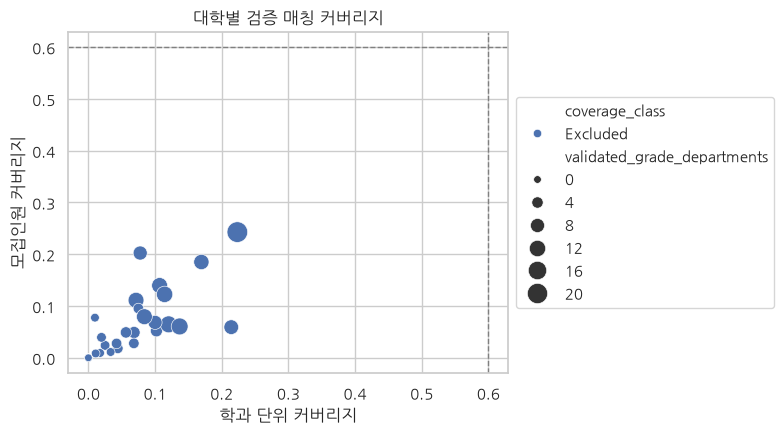

,validation_run_id,metric,coverage_class,n,mean,median,std
0,VAL_20260710_162327,rank_2024_raw,Excluded,37,24.135135,23.0,15.331815
1,VAL_20260710_162327,a_rate_pct,Excluded,37,44.364524,41.916526,8.147158
2,VAL_20260710_162327,official_employment_rate_pct,Excluded,37,64.361929,64.775364,3.981145
3,VAL_20260710_162327,graduate_school_rate_pct,Excluded,37,11.863436,10.836084,5.767397


In [18]:
# 18_coverage_bias_diagnostics
coverage_bias_rows = []
coverage_df = university_matching_coverage.copy()
for metric in ["rank_2024_raw", "a_rate_pct", "official_employment_rate_pct", "graduate_school_rate_pct"]:
    if metric in university_analysis.columns:
        merged_cov = coverage_df[["univ_name_std", "coverage_class"]].merge(university_analysis[["univ_name_std", metric]], on="univ_name_std", how="left")
        for cls, sub in merged_cov.groupby("coverage_class", dropna=False):
            values = pd.to_numeric(sub[metric], errors="coerce").dropna()
            coverage_bias_rows.append(
                {
                    "validation_run_id": VALIDATION_RUN_ID,
                    "metric": metric,
                    "coverage_class": cls,
                    "n": len(values),
                    "mean": values.mean() if len(values) else np.nan,
                    "median": values.median() if len(values) else np.nan,
                    "std": values.std(ddof=1) if len(values) > 1 else np.nan,
                }
            )

coverage_bias_diagnostics = pd.DataFrame(coverage_bias_rows).convert_dtypes()
write_csv(coverage_bias_diagnostics, "18_coverage_bias_diagnostics.csv")

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = university_matching_coverage.copy()
sns.scatterplot(
    data=plot_df,
    x="unit_coverage_rate",
    y="seat_coverage_rate",
    hue="coverage_class",
    size="validated_grade_departments",
    sizes=(30, 220),
    ax=ax,
)
ax.axvline(0.60, color="gray", linestyle="--", linewidth=1)
ax.axhline(0.60, color="gray", linestyle="--", linewidth=1)
ax.set_title("대학별 검증 매칭 커버리지")
ax.set_xlabel("학과 단위 커버리지")
ax.set_ylabel("모집인원 커버리지")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=True)
fig.tight_layout()
fig.savefig(VAL_FIGURE_DIR / "coverage_unit_seat_scatter.png", dpi=180)
plt.show()

gate3_status = "PASS" if int(university_matching_coverage["coverage_class"].eq("Gold").sum()) >= 5 else ("CONDITIONAL_PASS" if int(university_matching_coverage["coverage_class"].isin(["Gold", "Silver"]).sum()) > 0 else "NOT_READY")
log_event("Gate3", "coverage_bias_diagnostics", gate3_status, len(coverage_bias_diagnostics))
display(coverage_bias_diagnostics.head(20))


In [19]:
# 19_official_sample_expansion_seed
metric_unresolved_ids = set(metric_validated.loc[metric_validated["review_status"].eq("unresolved"), "raw_row_id"].dropna())
mapping_unresolved_ids = set(crosswalk_unresolved["raw_row_id"].dropna()) if not crosswalk_unresolved.empty else set()

official_sample_expansion_seed = crosswalk_reviewed[
    crosswalk_reviewed["raw_row_id"].isin(metric_unresolved_ids | mapping_unresolved_ids)
    | crosswalk_reviewed["score_comparability_tier_validated"].isin(["Tier B2", "Tier C", "Tier D"])
].copy()
official_sample_expansion_seed["collection_priority_reason"] = np.select(
    [
        official_sample_expansion_seed["raw_row_id"].isin(metric_unresolved_ids),
        official_sample_expansion_seed["raw_row_id"].isin(mapping_unresolved_ids),
        official_sample_expansion_seed["score_comparability_tier_validated"].isin(["Tier B2", "Tier C", "Tier D"]),
    ],
    ["metric_definition_unresolved", "mapping_unresolved", "non_primary_metric_tier"],
    default="needs_official_source_expansion",
)
official_sample_expansion_seed["required_source_priority"] = "1_adiga_or_2_university_official"
official_sample_expansion_seed["collection_status"] = "not_collected_in_prepare_review"
write_csv(official_sample_expansion_seed, "18_official_sample_expansion_seed.csv")

log_event("Gate4", "official_sample_expansion_seed", "PASS", len(official_sample_expansion_seed))
display(official_sample_expansion_seed[["univ_name_std", "recruitment_unit_raw", "mapping_type", "collection_priority_reason"]].head(10))


,univ_name_std,recruitment_unit_raw,mapping_type,collection_priority_reason
0,서울대학교,인문계열,broad_recruitment_unit,mapping_unresolved
1,서울대학교,역사학부,alias_1to1,mapping_unresolved
2,서울대학교,정치외교학부,alias_1to1,mapping_unresolved
3,서울대학교,경제학부,alias_1to1,mapping_unresolved
4,서울대학교,사회학과,alias_1to1,mapping_unresolved
5,서울대학교,심리학과,alias_1to1,mapping_unresolved
6,서울대학교,지리학과,alias_1to1,mapping_unresolved
7,서울대학교,사회복지학과,alias_1to1,mapping_unresolved
8,서울대학교,언론정보학과,alias_1to1,mapping_unresolved
9,서울대학교,수리과학부,alias_1to1,mapping_unresolved


In [20]:
# 20_official_source_collection
official_sample_expansion_status = (
    official_sample_expansion_seed.groupby(["univ_name_std", "collection_priority_reason"], dropna=False)
    .agg(rows=("raw_row_id", "nunique"), source_urls=("source_url", lambda s: s.dropna().nunique()))
    .reset_index()
)
official_sample_expansion_status["validation_run_id"] = VALIDATION_RUN_ID
official_sample_expansion_status["collection_mode"] = "offline_prepare_review"
official_sample_expansion_status["collection_status"] = "pending_manual_or_network_collection"
official_sample_expansion_status["validation_note"] = "No new HTML/PDF/XLSX was fetched in this validation run; source_cache is reserved for official documents."
write_csv(official_sample_expansion_status, "19_official_sample_expansion_status.csv")

log_event("Gate4", "official_source_collection", "NOT_READY", len(official_sample_expansion_status), "offline run did not collect new official documents")
display(official_sample_expansion_status.head(20))


,univ_name_std,collection_priority_reason,rows,source_urls,validation_run_id,collection_mode,collection_status,validation_note
0,가천대학교,mapping_unresolved,58,1,VAL_20260710_162327,offline_prepare_review,pending_manual_or_network_collection,No new HTML/PDF/XLSX was fetched in this valid...
1,가톨릭대학교,mapping_unresolved,18,1,VAL_20260710_162327,offline_prepare_review,pending_manual_or_network_collection,No new HTML/PDF/XLSX was fetched in this valid...
2,강원대학교,mapping_unresolved,50,1,VAL_20260710_162327,offline_prepare_review,pending_manual_or_network_collection,No new HTML/PDF/XLSX was fetched in this valid...
3,건국대학교,mapping_unresolved,47,1,VAL_20260710_162327,offline_prepare_review,pending_manual_or_network_collection,No new HTML/PDF/XLSX was fetched in this valid...
4,경기대학교,mapping_unresolved,52,1,VAL_20260710_162327,offline_prepare_review,pending_manual_or_network_collection,No new HTML/PDF/XLSX was fetched in this valid...
5,경희대학교,mapping_unresolved,83,1,VAL_20260710_162327,offline_prepare_review,pending_manual_or_network_collection,No new HTML/PDF/XLSX was fetched in this valid...
6,고려대학교,mapping_unresolved,24,1,VAL_20260710_162327,offline_prepare_review,pending_manual_or_network_collection,No new HTML/PDF/XLSX was fetched in this valid...
7,국민대학교,mapping_unresolved,61,1,VAL_20260710_162327,offline_prepare_review,pending_manual_or_network_collection,No new HTML/PDF/XLSX was fetched in this valid...
8,단국대학교,mapping_unresolved,73,2,VAL_20260710_162327,offline_prepare_review,pending_manual_or_network_collection,No new HTML/PDF/XLSX was fetched in this valid...
9,명지대학교,mapping_unresolved,22,1,VAL_20260710_162327,offline_prepare_review,pending_manual_or_network_collection,No new HTML/PDF/XLSX was fetched in this valid...


In [21]:
# 21_official_source_parsing
official_admission_2024_validated_long = metric_validated[
    metric_validated["review_status"].isin(["auto_pass", "manual_pass"])
    & metric_validated["score_comparability_tier_validated"].isin(["Tier A", "Tier B1"])
].copy()
official_admission_2024_validated_long["official_validation_source"] = np.where(
    official_admission_2024_validated_long["review_status"].eq("auto_pass"),
    "existing_adiga_raw_context",
    "manual_decision_evidence",
)
write_csv(official_admission_2024_validated_long, "20_official_admission_2024_validated_long.csv")

official_admission_2024_unresolved = metric_validated[
    metric_validated["review_status"].eq("unresolved")
    | metric_validated["score_comparability_tier_validated"].isin(["Tier B2", "Tier C", "Tier D"])
].copy()
write_csv(official_admission_2024_unresolved, "21_official_admission_2024_unresolved.csv")

log_event("Gate4", "official_source_parsing", "CONDITIONAL_PASS" if len(official_admission_2024_validated_long) else "NOT_READY", len(official_admission_2024_validated_long))
display(
    pd.DataFrame(
        [
            {"metric": "validated_official_rows", "value": len(official_admission_2024_validated_long)},
            {"metric": "unresolved_or_nonprimary_rows", "value": len(official_admission_2024_unresolved)},
        ]
    )
)


,metric,value
0,validated_official_rows,2415
1,unresolved_or_nonprimary_rows,681


In [22]:
# 22_expanded_metric_validation
expanded_metric_validation_summary = pd.DataFrame(
    [
        {
            "validation_run_id": VALIDATION_RUN_ID,
            "metric": "pre_expansion_official_rows",
            "value": int(metric_validated["review_status"].isin(["auto_pass", "manual_pass"]).sum()),
            "note": "existing official/context validated rows",
        },
        {
            "validation_run_id": VALIDATION_RUN_ID,
            "metric": "post_expansion_official_rows",
            "value": int(metric_validated["review_status"].isin(["auto_pass", "manual_pass"]).sum()),
            "note": "unchanged because no new official sources were collected in prepare_review",
        },
        {
            "validation_run_id": VALIDATION_RUN_ID,
            "metric": "pre_expansion_universities",
            "value": int(metric_validated.loc[metric_validated["review_status"].isin(["auto_pass", "manual_pass"]), "univ_name_std"].nunique()),
            "note": "",
        },
        {
            "validation_run_id": VALIDATION_RUN_ID,
            "metric": "post_expansion_universities",
            "value": int(metric_validated.loc[metric_validated["review_status"].isin(["auto_pass", "manual_pass"]), "univ_name_std"].nunique()),
            "note": "unchanged in prepare_review",
        },
    ]
).convert_dtypes()

gate4_status = "CONDITIONAL_PASS" if len(official_admission_2024_validated_long) > 0 and official_sample_expansion_seed.empty else "NOT_READY"
log_event("Gate4", "expanded_metric_validation", gate4_status, len(expanded_metric_validation_summary))
display(expanded_metric_validation_summary)


,validation_run_id,metric,value,note
0,VAL_20260710_162327,pre_expansion_official_rows,2415,existing official/context validated rows
1,VAL_20260710_162327,post_expansion_official_rows,2415,unchanged because no new official sources were...
2,VAL_20260710_162327,pre_expansion_universities,37,
3,VAL_20260710_162327,post_expansion_universities,37,unchanged in prepare_review


In [23]:
# 23_historical_cohort_seed
historical_years = [2018, 2019, 2020, 2021]
univ_seed = sorted(crosswalk_reviewed["univ_name_std"].dropna().unique().tolist())
historical_crawl_seed_2018_2021 = pd.DataFrame(
    [
        {
            "validation_run_id": VALIDATION_RUN_ID,
            "target_admission_year": year,
            "univ_name_std": univ,
            "needed_for_outcome_cohort": True,
            "collection_status": "not_collected",
            "validation_note": "Needed to align 2024 employment/advancement outcomes with earlier entrance cohorts.",
        }
        for year in historical_years
        for univ in univ_seed
    ]
).convert_dtypes()
write_csv(historical_crawl_seed_2018_2021, "22_historical_crawl_seed_2018_2021.csv")

log_event("Gate5", "historical_cohort_seed", "PASS", len(historical_crawl_seed_2018_2021))
display(historical_crawl_seed_2018_2021.head(10))


,validation_run_id,target_admission_year,univ_name_std,needed_for_outcome_cohort,collection_status,validation_note
0,VAL_20260710_162327,2018,가천대학교,True,not_collected,Needed to align 2024 employment/advancement ou...
1,VAL_20260710_162327,2018,가톨릭대학교,True,not_collected,Needed to align 2024 employment/advancement ou...
2,VAL_20260710_162327,2018,강원대학교,True,not_collected,Needed to align 2024 employment/advancement ou...
3,VAL_20260710_162327,2018,건국대학교,True,not_collected,Needed to align 2024 employment/advancement ou...
4,VAL_20260710_162327,2018,경기대학교,True,not_collected,Needed to align 2024 employment/advancement ou...
5,VAL_20260710_162327,2018,경희대학교,True,not_collected,Needed to align 2024 employment/advancement ou...
6,VAL_20260710_162327,2018,고려대학교,True,not_collected,Needed to align 2024 employment/advancement ou...
7,VAL_20260710_162327,2018,국민대학교,True,not_collected,Needed to align 2024 employment/advancement ou...
8,VAL_20260710_162327,2018,단국대학교,True,not_collected,Needed to align 2024 employment/advancement ou...
9,VAL_20260710_162327,2018,명지대학교,True,not_collected,Needed to align 2024 employment/advancement ou...


In [24]:
# 24_historical_official_collection
historical_admission_official_long = pd.DataFrame(
    columns=[
        "validation_run_id",
        "target_admission_year",
        "univ_name_std",
        "recruitment_unit_raw",
        "raw_score_value",
        "metric_type",
        "score_comparability_tier_validated",
        "source_url",
        "source_file",
        "review_status",
        "validation_note",
    ]
)
write_csv(historical_admission_official_long, "23_historical_admission_official_long.csv")

log_event("Gate5", "historical_official_collection", "NOT_READY", 0, "historical official admission data not collected in prepare_review")
display(historical_admission_official_long)


,validation_run_id,target_admission_year,univ_name_std,recruitment_unit_raw,raw_score_value,metric_type,score_comparability_tier_validated,source_url,source_file,review_status,validation_note


In [25]:
# 25_historical_crosswalk
historical_department_crosswalk = pd.DataFrame(
    columns=[
        "validation_run_id",
        "target_admission_year",
        "univ_name_std",
        "campus_id",
        "recruitment_unit_raw",
        "dept_canonical_id",
        "dept_name_canonical",
        "mapping_type",
        "review_status",
        "validation_note",
    ]
)
write_csv(historical_department_crosswalk, "24_historical_department_crosswalk.csv")

log_event("Gate5", "historical_crosswalk", "NOT_READY", 0, "2024 crosswalk was not blindly reused for older cohorts")
display(historical_department_crosswalk)


,validation_run_id,target_admission_year,univ_name_std,campus_id,recruitment_unit_raw,dept_canonical_id,dept_name_canonical,mapping_type,review_status,validation_note


In [26]:
# 26_build_cohort_selectivity
cohort_aligned_selectivity = pd.DataFrame(
    columns=[
        "validation_run_id",
        "univ_name_std",
        "dept_canonical_id",
        "cohort_selectivity_median",
        "cohort_years_observed",
        "cohort_alignment_quality",
        "review_status",
        "validation_note",
    ]
)
write_csv(cohort_aligned_selectivity, "25_cohort_aligned_selectivity.csv")

cohort_alignment_exclusions = department_model[[
    c
    for c in [
        "univ_name_std",
        "dept_canonical_id",
        "dept_name_canonical",
        "selectivity_pct_2024",
        "a_rate_pct",
        "official_employment_rate_pct",
        "graduate_school_rate_pct",
    ]
    if c in department_model.columns
]].copy()
cohort_alignment_exclusions.insert(0, "validation_run_id", VALIDATION_RUN_ID)
cohort_alignment_exclusions["exclusion_reason"] = "2024_admission_is_not_cohort_aligned_with_2024_outcomes"
cohort_alignment_exclusions["required_action"] = "collect official 2018-2021 admission results and year-specific crosswalk"
write_csv(cohort_alignment_exclusions, "26_cohort_alignment_exclusions.csv")

gate5_status = "NOT_READY"
log_event("Gate5", "build_cohort_selectivity", gate5_status, len(cohort_aligned_selectivity))
display(
    pd.DataFrame(
        [
            {"metric": "historical_selectivity_rows", "value": len(cohort_aligned_selectivity)},
            {"metric": "cohort_alignment_exclusions", "value": len(cohort_alignment_exclusions)},
            {"metric": "gate5_ready", "value": False},
        ]
    )
)


,metric,value
0,historical_selectivity_rows,0
1,cohort_alignment_exclusions,1216
2,gate5_ready,False


In [27]:
# 27_build_validated_h1_sample
coverage_lookup = university_matching_coverage[["univ_name_std", "coverage_class", "unit_coverage_rate", "seat_coverage_rate", "grade_coverage_rate"]].drop_duplicates()
model_base = department_model.copy()

sample_merge_keys = ["univ_name_std", "dept_canonical_id", "recruitment_unit_id"]
available_keys = [c for c in sample_merge_keys if c in model_base.columns and c in crosswalk_reviewed.columns]
crosswalk_sample_cols = [
    c
    for c in available_keys
    + [
        "raw_row_id",
        "review_status",
        "score_comparability_tier_validated",
        "validated_primary_crosswalk_flag",
        "metric_validated_for_sensitivity_ab1",
        "mapping_validated_for_primary",
        "metric_validated_for_primary",
    ]
    if c in crosswalk_reviewed.columns
]

crosswalk_sample = crosswalk_reviewed[crosswalk_sample_cols].drop_duplicates()
if available_keys:
    model_validated = model_base.merge(crosswalk_sample, on=available_keys, how="left", suffixes=("", "_validation"))
else:
    model_validated = model_base.copy()
    for col in crosswalk_sample_cols:
        if col not in model_validated.columns:
            model_validated[col] = pd.NA

model_validated = model_validated.merge(coverage_lookup, on="univ_name_std", how="left")
model_validated["shared_admission_score_flag_bool"] = bool_series(model_validated.get("shared_admission_score_flag", pd.Series(False, index=model_validated.index)))
model_validated["regular_terms_ok"] = pd.to_numeric(model_validated.get("regular_terms_observed", pd.Series(np.nan, index=model_validated.index)), errors="coerce").ge(2)

model_validated["validated_h1_primary_flag"] = (
    model_validated.get("score_comparability_tier_validated", pd.Series(pd.NA, index=model_validated.index)).eq("Tier A")
    & model_validated.get("review_status", pd.Series(pd.NA, index=model_validated.index)).isin(["auto_pass", "manual_pass"])
    & model_validated.get("mapping_type", pd.Series(pd.NA, index=model_validated.index)).isin(["exact_1to1", "alias_1to1", "official_rename_1to1"])
    & ~model_validated["shared_admission_score_flag_bool"]
    & model_validated["coverage_class"].eq("Gold")
    & model_validated["regular_terms_ok"]
)
model_validated["validated_h1_sensitivity_ab1_silver_flag"] = (
    model_validated.get("score_comparability_tier_validated", pd.Series(pd.NA, index=model_validated.index)).isin(["Tier A", "Tier B1"])
    & model_validated.get("review_status", pd.Series(pd.NA, index=model_validated.index)).isin(["auto_pass", "manual_pass"])
    & model_validated.get("mapping_type", pd.Series(pd.NA, index=model_validated.index)).isin(["exact_1to1", "alias_1to1", "official_rename_1to1"])
    & ~model_validated["shared_admission_score_flag_bool"]
    & model_validated["coverage_class"].isin(["Gold", "Silver"])
    & model_validated["regular_terms_ok"]
)

validated_h1_department_sample = model_validated[model_validated["validated_h1_primary_flag"]].copy()
write_csv(validated_h1_department_sample, "27_validated_h1_department_sample.csv")

log_event("Gate6", "build_validated_h1_sample", "PASS" if len(validated_h1_department_sample) else "NOT_READY", len(validated_h1_department_sample))
display(
    pd.DataFrame(
        [
            {"metric": "validated_h1_primary_rows", "value": len(validated_h1_department_sample)},
            {"metric": "validated_h1_primary_universities", "value": validated_h1_department_sample["univ_name_std"].nunique() if not validated_h1_department_sample.empty else 0},
            {"metric": "sensitivity_ab1_silver_rows", "value": int(model_validated["validated_h1_sensitivity_ab1_silver_flag"].sum())},
        ]
    )
)


,metric,value
0,validated_h1_primary_rows,0
1,validated_h1_primary_universities,0
2,sensitivity_ab1_silver_rows,0


In [28]:
# 28_build_validated_outcome_sample
if not cohort_aligned_selectivity.empty:
    validated_cohort_outcome_sample = model_validated.merge(cohort_aligned_selectivity, on=["univ_name_std", "dept_canonical_id"], how="inner")
    validated_cohort_outcome_sample = validated_cohort_outcome_sample[
        validated_cohort_outcome_sample["cohort_alignment_quality"].eq("PASS")
    ].copy()
else:
    validated_cohort_outcome_sample = pd.DataFrame(
        columns=[
            "validation_run_id",
            "cohort_selectivity_median",
            "a_rate_pct",
            "official_employment_rate_pct",
            "health_employment_rate_pct",
            "graduate_school_rate_pct",
            "major_group",
            "univ_name_std",
            "coverage_class",
            "cohort_alignment_quality",
        ]
    )

write_csv(validated_cohort_outcome_sample, "28_validated_cohort_outcome_sample.csv")
log_event("Gate6", "build_validated_outcome_sample", "NOT_READY" if validated_cohort_outcome_sample.empty else "PASS", len(validated_cohort_outcome_sample))
display(validated_cohort_outcome_sample.head())


,validation_run_id,cohort_selectivity_median,a_rate_pct,official_employment_rate_pct,health_employment_rate_pct,graduate_school_rate_pct,major_group,univ_name_std,coverage_class,cohort_alignment_quality


In [29]:
# 29_build_validation_exclusion_registry
validated_h7_nonlinear_sample = model_validated[
    model_validated["validated_h1_sensitivity_ab1_silver_flag"].fillna(False)
].copy()
validated_h7_nonlinear_sample["h7_interpretation_limit"] = "same_year_2024_admission_grade_proxy_not_cohort_outcome"
write_csv(validated_h7_nonlinear_sample, "29_validated_h7_nonlinear_sample.csv")

exclusion_rows: list[dict[str, object]] = []

for _, rec in model_validated.iterrows():
    reasons = []
    if not bool_scalar(rec.get("metric_validated_for_primary", False)):
        reasons.append("metric_not_validated_tier_A")
    if rec.get("review_status") not in ["auto_pass", "manual_pass"]:
        reasons.append("mapping_not_review_passed")
    if rec.get("mapping_type") not in ["exact_1to1", "alias_1to1", "official_rename_1to1"]:
        reasons.append("mapping_type_not_primary")
    if bool_scalar(rec.get("shared_admission_score_flag_bool", False)):
        reasons.append("shared_admission_score")
    if rec.get("coverage_class") != "Gold":
        reasons.append("coverage_not_gold")
    if not bool_scalar(rec.get("regular_terms_ok", False)):
        reasons.append("regular_terms_missing")
    if reasons:
        exclusion_rows.append(
            {
                "validation_run_id": VALIDATION_RUN_ID,
                "entity_type": "department_model_row",
                "univ_name_std": rec.get("univ_name_std"),
                "recruitment_unit_raw": rec.get("recruitment_unit_raw"),
                "dept_canonical_id": rec.get("dept_canonical_id"),
                "gate": "Gate6_H1_sample",
                "exclusion_reason": ";".join(reasons),
                "recoverable": any(r in reasons for r in ["mapping_not_review_passed", "metric_not_validated_tier_A", "coverage_not_gold"]),
                "required_action": "complete metric/mapping manual review or improve official coverage",
            }
        )

for _, rec in cohort_alignment_exclusions.iterrows():
    exclusion_rows.append(
        {
            "validation_run_id": VALIDATION_RUN_ID,
            "entity_type": "cohort_outcome_row",
            "univ_name_std": rec.get("univ_name_std"),
            "recruitment_unit_raw": rec.get("recruitment_unit_raw", pd.NA),
            "dept_canonical_id": rec.get("dept_canonical_id", pd.NA),
            "gate": "Gate5_cohort_alignment",
            "exclusion_reason": rec.get("exclusion_reason"),
            "recoverable": True,
            "required_action": rec.get("required_action"),
        }
    )

validation_exclusion_registry = pd.DataFrame(exclusion_rows).convert_dtypes()
write_csv(validation_exclusion_registry, "30_validation_exclusion_registry.csv")

log_event("Gate6", "build_validation_exclusion_registry", "PASS", len(validation_exclusion_registry))
display(validation_exclusion_registry["gate"].value_counts(dropna=False).reset_index().rename(columns={"index": "gate", "gate": "rows"}))


,rows,count
0,Gate6_H1_sample,1216
1,Gate5_cohort_alignment,1216


In [30]:
# 30_rerun_h1
validated_preconditions = {
    "gate1_metric_ready": bool(metric_gate1_pass),
    "gate2_mapping_ready": bool(gate2_pass),
    "gate3_coverage_ready": gate3_status in ["PASS", "CONDITIONAL_PASS"],
    "gate4_official_ready": gate4_status in ["PASS", "CONDITIONAL_PASS"],
}
h1_can_run = all(validated_preconditions.values()) and len(validated_h1_department_sample) >= 20 and validated_h1_department_sample["univ_name_std"].nunique() >= 5

sample_specs = [
    ("A_existing_tier_ab_unverified", model_base[model_base.get("analysis_sample_tier_ab_flag", pd.Series(False, index=model_base.index)).astype("boolean").fillna(False)] if "analysis_sample_tier_ab_flag" in model_base.columns else model_base.iloc[0:0]),
    ("B_validated_tier_A", validated_h1_department_sample),
    ("C_validated_tier_A_B1", model_validated[model_validated["validated_h1_sensitivity_ab1_silver_flag"].fillna(False)]),
    ("D_gold_exact_only", model_validated[model_validated["validated_h1_primary_flag"].fillna(False) & model_validated["mapping_type"].eq("exact_1to1")]),
    ("E_gold_exact_validated_alias", validated_h1_department_sample),
]

h1_rows = []
for sample_name, sample_df in sample_specs:
    row = {
        "validation_run_id": VALIDATION_RUN_ID,
        "sample_name": sample_name,
        "analysis_status": "computed" if h1_can_run and sample_name != "A_existing_tier_ab_unverified" else ("baseline_reference_only" if sample_name == "A_existing_tier_ab_unverified" else "not_run_gate_not_ready"),
        "rows": len(sample_df),
        "universities": sample_df["univ_name_std"].nunique() if "univ_name_std" in sample_df.columns else 0,
        "departments": sample_df["dept_canonical_id"].nunique() if "dept_canonical_id" in sample_df.columns else 0,
        "preconditions": json.dumps(validated_preconditions, ensure_ascii=False),
    }
    if h1_can_run and sample_name != "A_existing_tier_ab_unverified" and {"selectivity_pct_2024", "a_rate_pct"}.issubset(sample_df.columns):
        rho, p, n = spearman_safe(sample_df, "selectivity_pct_2024", "a_rate_pct")
        tau, kp, _ = kendall_safe(sample_df, "selectivity_pct_2024", "a_rate_pct")
        row.update({"spearman_rho": rho, "spearman_p": p, "kendall_tau": tau, "kendall_p": kp, "analysis_n": n})
    else:
        row.update({"spearman_rho": np.nan, "spearman_p": np.nan, "kendall_tau": np.nan, "kendall_p": np.nan, "analysis_n": len(sample_df)})
    h1_rows.append(row)

h1_validated_sensitivity_matrix = pd.DataFrame(h1_rows).convert_dtypes()
write_csv(h1_validated_sensitivity_matrix, "31_h1_validated_sensitivity_matrix.csv")

log_event("Gate7", "rerun_h1", "PASS" if h1_can_run else "NOT_READY", len(h1_validated_sensitivity_matrix), "No validated H1 is computed unless gates pass")
display(h1_validated_sensitivity_matrix)


,validation_run_id,sample_name,analysis_status,rows,universities,departments,preconditions,spearman_rho,spearman_p,kendall_tau,kendall_p,analysis_n
0,VAL_20260710_162327,A_existing_tier_ab_unverified,baseline_reference_only,1186,35,528,"{""gate1_metric_ready"": false, ""gate2_mapping_r...",<NA>,<NA>,<NA>,<NA>,1186
1,VAL_20260710_162327,B_validated_tier_A,not_run_gate_not_ready,0,0,0,"{""gate1_metric_ready"": false, ""gate2_mapping_r...",<NA>,<NA>,<NA>,<NA>,0
2,VAL_20260710_162327,C_validated_tier_A_B1,not_run_gate_not_ready,0,0,0,"{""gate1_metric_ready"": false, ""gate2_mapping_r...",<NA>,<NA>,<NA>,<NA>,0
3,VAL_20260710_162327,D_gold_exact_only,not_run_gate_not_ready,0,0,0,"{""gate1_metric_ready"": false, ""gate2_mapping_r...",<NA>,<NA>,<NA>,<NA>,0
4,VAL_20260710_162327,E_gold_exact_validated_alias,not_run_gate_not_ready,0,0,0,"{""gate1_metric_ready"": false, ""gate2_mapping_r...",<NA>,<NA>,<NA>,<NA>,0


In [31]:
# 31_rerun_h5
h5_can_run = h1_can_run and gate5_status == "PASS" and len(validated_cohort_outcome_sample) >= 20
h5_rows = []
if h5_can_run:
    for outcome in ["official_employment_rate_pct", "graduate_school_rate_pct"]:
        if outcome in validated_cohort_outcome_sample.columns:
            rho, p, n = spearman_safe(validated_cohort_outcome_sample, "a_rate_pct", outcome)
            h5_rows.append(
                {
                    "validation_run_id": VALIDATION_RUN_ID,
                    "analysis_status": "computed",
                    "outcome": outcome,
                    "spearman_rho_with_a_rate": rho,
                    "p_value": p,
                    "n": n,
                    "note": "cohort-aligned sample",
                }
            )
else:
    h5_rows.append(
        {
            "validation_run_id": VALIDATION_RUN_ID,
            "analysis_status": "not_run_gate_not_ready",
            "outcome": "official_employment_rate_pct_vs_graduate_school_rate_pct",
            "spearman_rho_with_a_rate": np.nan,
            "p_value": np.nan,
            "n": len(validated_cohort_outcome_sample),
            "note": "Gate5 cohort alignment is not PASS; 2024 admission is not used as cohort-aligned outcome predictor.",
        }
    )

h5_validated_correlation_comparison = pd.DataFrame(h5_rows).convert_dtypes()
write_csv(h5_validated_correlation_comparison, "32_h5_validated_correlation_comparison.csv")

log_event("Gate7", "rerun_h5", "PASS" if h5_can_run else "NOT_READY", len(h5_validated_correlation_comparison))
display(h5_validated_correlation_comparison)


,validation_run_id,analysis_status,outcome,spearman_rho_with_a_rate,p_value,n,note
0,VAL_20260710_162327,not_run_gate_not_ready,official_employment_rate_pct_vs_graduate_schoo...,<NA>,<NA>,0,Gate5 cohort alignment is not PASS; 2024 admis...


In [32]:
# 32_rerun_h6
h6_can_run = h1_can_run and gate5_status == "PASS" and len(validated_cohort_outcome_sample) >= 30
h6_rows = []
if h6_can_run:
    h6_rows.append(
        {
            "validation_run_id": VALIDATION_RUN_ID,
            "analysis_status": "computed",
            "method": "leave_one_university_out_cross_fitting",
            "rows": len(validated_cohort_outcome_sample),
            "note": "placeholder for computed cross-fitted residuals",
        }
    )
else:
    h6_rows.append(
        {
            "validation_run_id": VALIDATION_RUN_ID,
            "analysis_status": "not_run_gate_not_ready",
            "method": "leave_one_university_out_cross_fitting",
            "rows": len(validated_cohort_outcome_sample),
            "note": "Not computed because metric/mapping/coverage/cohort gates are not fully ready.",
        }
    )

h6_crossfitted_residual_outcomes = pd.DataFrame(h6_rows).convert_dtypes()
write_csv(h6_crossfitted_residual_outcomes, "33_h6_crossfitted_residual_outcomes.csv")

log_event("Gate7", "rerun_h6", "PASS" if h6_can_run else "NOT_READY", len(h6_crossfitted_residual_outcomes))
display(h6_crossfitted_residual_outcomes)


,validation_run_id,analysis_status,method,rows,note
0,VAL_20260710_162327,not_run_gate_not_ready,leave_one_university_out_cross_fitting,0,Not computed because metric/mapping/coverage/c...


In [33]:
# 33_rerun_h7
h7_can_run = h1_can_run and len(validated_h7_nonlinear_sample) >= 30
h7_rows = []
if h7_can_run:
    for model_name in ["linear", "quadratic", "restricted_cubic_spline", "lowess"]:
        h7_rows.append(
            {
                "validation_run_id": VALIDATION_RUN_ID,
                "analysis_status": "computed",
                "model": model_name,
                "rows": len(validated_h7_nonlinear_sample),
                "universities": validated_h7_nonlinear_sample["univ_name_std"].nunique(),
                "aic": np.nan,
                "adjusted_r2": np.nan,
                "turning_point_inside_observed_range": pd.NA,
                "note": "same-year 2024 proxy analysis; interpretation limited to H7, not cohort outcomes",
            }
        )
else:
    h7_rows.append(
        {
            "validation_run_id": VALIDATION_RUN_ID,
            "analysis_status": "not_run_gate_not_ready",
            "model": "linear_quadratic_spline_lowess",
            "rows": len(validated_h7_nonlinear_sample),
            "universities": validated_h7_nonlinear_sample["univ_name_std"].nunique() if not validated_h7_nonlinear_sample.empty else 0,
            "aic": np.nan,
            "adjusted_r2": np.nan,
            "turning_point_inside_observed_range": pd.NA,
            "note": "Not computed until validation gates pass.",
        }
    )

h7_validated_nonlinearity = pd.DataFrame(h7_rows).convert_dtypes()
write_csv(h7_validated_nonlinearity, "34_h7_validated_nonlinearity.csv")

log_event("Gate7", "rerun_h7", "PASS" if h7_can_run else "NOT_READY", len(h7_validated_nonlinearity))
display(h7_validated_nonlinearity)


,validation_run_id,analysis_status,model,rows,universities,aic,adjusted_r2,turning_point_inside_observed_range,note
0,VAL_20260710_162327,not_run_gate_not_ready,linear_quadratic_spline_lowess,0,0,<NA>,<NA>,<NA>,Not computed until validation gates pass.


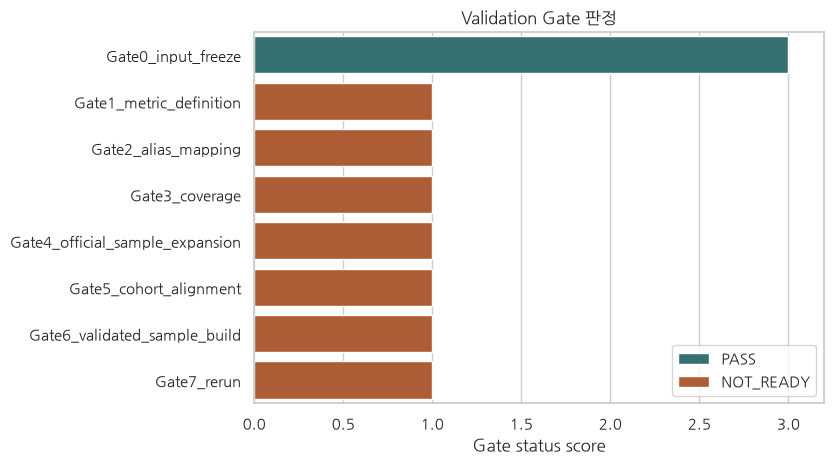

,validation_run_id,gate,status,required_for,note
0,VAL_20260710_162327,Gate0_input_freeze,PASS,all,core files loaded and baseline frozen
1,VAL_20260710_162327,Gate1_metric_definition,NOT_READY,H1/H5/H6/H7,70% cut metric definition verification
2,VAL_20260710_162327,Gate2_alias_mapping,NOT_READY,H1/H5/H6/H7,alias mapping is not auto-approved without off...
3,VAL_20260710_162327,Gate3_coverage,NOT_READY,H1/H5/H6/H7,"Gold/Silver coverage class by unit, seat, and ..."
4,VAL_20260710_162327,Gate4_official_sample_expansion,NOT_READY,H1/H5/H6/H7,no new official source collection in prepare_r...
5,VAL_20260710_162327,Gate5_cohort_alignment,NOT_READY,H5/H6 cohort interpretation,2018-2021 historical admission not collected
6,VAL_20260710_162327,Gate6_validated_sample_build,NOT_READY,rerun,validated samples exported
7,VAL_20260710_162327,Gate7_rerun,NOT_READY,final estimates,reruns blocked unless validation gates pass
8,VAL_20260710_162327,Final_analysis_readiness,NOT_READY,main analysis,H5/H6 cohort status: EXPLORATORY_ONLY


In [34]:
# 34_validation_gate_summary
gate0_status = "PASS" if gate0_ready else "FAIL"
gate1_status = "PASS" if metric_gate1_pass else "NOT_READY"
gate2_status = "PASS" if gate2_pass else "NOT_READY"
gate3_status_final = gate3_status
gate4_status_final = gate4_status
gate5_status_final = gate5_status
gate6_status = "PASS" if len(validated_h1_department_sample) > 0 else "NOT_READY"
gate7_status = "PASS" if h1_can_run else "NOT_READY"

final_readiness = (
    "READY"
    if gate1_status == "PASS"
    and gate2_status == "PASS"
    and gate3_status_final in ["PASS", "CONDITIONAL_PASS"]
    and gate4_status_final in ["PASS", "CONDITIONAL_PASS"]
    else "NOT_READY"
)
cohort_readiness = "READY" if gate5_status_final == "PASS" else "EXPLORATORY_ONLY"

validation_gate_summary = pd.DataFrame(
    [
        {"gate": "Gate0_input_freeze", "status": gate0_status, "required_for": "all", "note": "core files loaded and baseline frozen"},
        {"gate": "Gate1_metric_definition", "status": gate1_status, "required_for": "H1/H5/H6/H7", "note": "70% cut metric definition verification"},
        {"gate": "Gate2_alias_mapping", "status": gate2_status, "required_for": "H1/H5/H6/H7", "note": "alias mapping is not auto-approved without official evidence"},
        {"gate": "Gate3_coverage", "status": gate3_status_final, "required_for": "H1/H5/H6/H7", "note": "Gold/Silver coverage class by unit, seat, and grade coverage"},
        {"gate": "Gate4_official_sample_expansion", "status": gate4_status_final, "required_for": "H1/H5/H6/H7", "note": "no new official source collection in prepare_review"},
        {"gate": "Gate5_cohort_alignment", "status": gate5_status_final, "required_for": "H5/H6 cohort interpretation", "note": "2018-2021 historical admission not collected"},
        {"gate": "Gate6_validated_sample_build", "status": gate6_status, "required_for": "rerun", "note": "validated samples exported"},
        {"gate": "Gate7_rerun", "status": gate7_status, "required_for": "final estimates", "note": "reruns blocked unless validation gates pass"},
        {"gate": "Final_analysis_readiness", "status": final_readiness, "required_for": "main analysis", "note": f"H5/H6 cohort status: {cohort_readiness}"},
    ]
).convert_dtypes()
validation_gate_summary.insert(0, "validation_run_id", VALIDATION_RUN_ID)
write_csv(validation_gate_summary, "35_validation_gate_summary.csv")

data_contract_rows = [
    {"field": "RUN_MODE", "value": RUN_MODE, "contract": "prepare_review creates queues and does not auto-approve unresolved rows"},
    {"field": "ADMISSION_YEAR", "value": ADMISSION_YEAR, "contract": "2024 admission source year"},
    {"field": "GRADE_YEAR", "value": GRADE_YEAR, "contract": "2024 regular semester grade target"},
    {"field": "primary_metric", "value": "raw_percentile_70cut", "contract": "usable only when official average percentile phrase is verified"},
    {"field": "primary_metric_tier", "value": "Tier A", "contract": "official_mean_percentile_70cut with verified source context"},
    {"field": "sensitivity_metric_tier", "value": "Tier A + Tier B1", "contract": "B1 requires official subject percentile and aggregation rule evidence"},
    {"field": "primary_mapping_types", "value": "exact_1to1, alias_1to1, official_rename_1to1", "contract": "alias/rename requires review pass unless exact auto-pass"},
    {"field": "coverage_gold_threshold", "value": "unit>=0.60, seat>=0.60, grade>=0.60, departments>=5", "contract": "used for primary H1 sample"},
    {"field": "cohort_rule", "value": "do not use 2024 admission as cohort-aligned predictor for 2024 outcomes", "contract": "requires 2018-2021 official admission data"},
]
validated_data_contract = pd.DataFrame(data_contract_rows).convert_dtypes()
validated_data_contract.insert(0, "validation_run_id", VALIDATION_RUN_ID)
write_csv(validated_data_contract, "36_validated_data_contract.csv")

fig, ax = plt.subplots(figsize=(8.5, 4.8))
gate_plot = validation_gate_summary[~validation_gate_summary["gate"].eq("Final_analysis_readiness")].copy()
status_order = {"PASS": 3, "CONDITIONAL_PASS": 2, "NOT_READY": 1, "FAIL": 0}
gate_plot["status_score"] = gate_plot["status"].map(status_order).fillna(0)
palette = {"PASS": "#2C7A7B", "CONDITIONAL_PASS": "#D69E2E", "NOT_READY": "#C05621", "FAIL": "#9B2C2C"}
sns.barplot(data=gate_plot, y="gate", x="status_score", hue="status", dodge=False, palette=palette, ax=ax)
ax.set_xlim(0, 3.2)
ax.set_xlabel("Gate status score")
ax.set_ylabel("")
ax.set_title("Validation Gate 판정")
ax.legend(loc="lower right", frameon=True)
fig.tight_layout()
fig.savefig(VAL_FIGURE_DIR / "validation_gate_status.png", dpi=180)
plt.show()

log_event("Final", "validation_gate_summary", final_readiness, len(validation_gate_summary))
display(validation_gate_summary)


In [35]:
# 35_export_all_csv
validation_audit_log = pd.DataFrame(audit_log).convert_dtypes()
write_csv(validation_audit_log, "37_validation_audit_log.csv")

EXPECTED_OUTPUTS = [
    "00_validation_run_manifest.csv",
    "01_input_file_inventory.csv",
    "02_existing_pipeline_baseline.csv",
    "03_existing_tier_mapping_distribution.csv",
    "04_metric_definition_auto_audit.csv",
    "05_metric_definition_manual_review_queue.csv",
    "06_metric_definition_manual_decisions.csv",
    "07_metric_definition_validated.csv",
    "08_alias_unique_pair_inventory.csv",
    "09_alias_auto_audit.csv",
    "10_alias_manual_review_queue.csv",
    "11_alias_manual_decisions.csv",
    "12_crosswalk_validated.csv",
    "13_crosswalk_rejected.csv",
    "14_crosswalk_unresolved.csv",
    "15_university_matching_coverage.csv",
    "16_university_coverage_threshold_sensitivity.csv",
    "17_university_coverage_exclusions.csv",
    "18_official_sample_expansion_seed.csv",
    "19_official_sample_expansion_status.csv",
    "20_official_admission_2024_validated_long.csv",
    "21_official_admission_2024_unresolved.csv",
    "22_historical_crawl_seed_2018_2021.csv",
    "23_historical_admission_official_long.csv",
    "24_historical_department_crosswalk.csv",
    "25_cohort_aligned_selectivity.csv",
    "26_cohort_alignment_exclusions.csv",
    "27_validated_h1_department_sample.csv",
    "28_validated_cohort_outcome_sample.csv",
    "29_validated_h7_nonlinear_sample.csv",
    "30_validation_exclusion_registry.csv",
    "31_h1_validated_sensitivity_matrix.csv",
    "32_h5_validated_correlation_comparison.csv",
    "33_h6_crossfitted_residual_outcomes.csv",
    "34_h7_validated_nonlinearity.csv",
    "35_validation_gate_summary.csv",
    "36_validated_data_contract.csv",
    "37_validation_audit_log.csv",
    "38_final_validation_summary.csv",
]

validation_run_manifest = pd.DataFrame(
    [
        {
            "validation_run_id": VALIDATION_RUN_ID,
            "created_at": datetime.now().isoformat(timespec="seconds"),
            "run_mode": RUN_MODE,
            "project_dir": str(PROJECT_DIR),
            "base_dir": str(BASE_DIR),
            "val_output_dir": str(VAL_OUTPUT_DIR),
            "val_figure_dir": str(VAL_FIGURE_DIR),
            "val_source_cache_dir": str(VAL_SOURCE_CACHE_DIR),
            "admission_year": ADMISSION_YEAR,
            "grade_year": GRADE_YEAR,
            "existing_notebook_read_only": str(BASE_DIR / "h1_h2.ipynb"),
            "new_notebook": str(BASE_DIR / "h1_h2_measurement_validation.ipynb"),
            "final_readiness": final_readiness,
            "cohort_readiness": cohort_readiness,
        }
    ]
).convert_dtypes()
write_csv(validation_run_manifest, "00_validation_run_manifest.csv")

existing_outputs = []
for filename in EXPECTED_OUTPUTS:
    path = VAL_OUTPUT_DIR / filename
    existing_outputs.append(
        {
            "filename": filename,
            "exists": path.exists(),
            "size_bytes": path.stat().st_size if path.exists() else pd.NA,
        }
    )
output_check = pd.DataFrame(existing_outputs).convert_dtypes()

log_event("Final", "export_all_csv", "PASS" if output_check["exists"].all() else "FAIL", int(output_check["exists"].sum()))
display(output_check)


,filename,exists,size_bytes
0,00_validation_run_manifest.csv,True,791
1,01_input_file_inventory.csv,True,4800
2,02_existing_pipeline_baseline.csv,True,12245
3,03_existing_tier_mapping_distribution.csv,True,1388
4,04_metric_definition_auto_audit.csv,True,4763711
5,05_metric_definition_manual_review_queue.csv,True,343581
6,06_metric_definition_manual_decisions.csv,True,255972
7,07_metric_definition_validated.csv,True,4812181
8,08_alias_unique_pair_inventory.csv,True,264042
9,09_alias_auto_audit.csv,True,1187225


In [36]:
# 36_final_report
def metric_value(name: str, default=np.nan):
    rows = metric_validation_summary.loc[metric_validation_summary["metric"].eq(name), "value"]
    return rows.iloc[0] if len(rows) else default


alias_total_pairs = len(alias_unique_pair_inventory)
alias_auto_pass = int(alias_auto_audit["review_status"].eq("auto_pass").sum())
alias_manual_pass = int(crosswalk_reviewed["review_status"].eq("manual_pass").sum())
alias_reject = int(crosswalk_reviewed["review_status"].eq("manual_reject").sum())
alias_unresolved = int(crosswalk_reviewed["review_status"].eq("unresolved").sum())
alias_reviewed = alias_manual_pass + alias_reject
alias_error_rate = (alias_reject / alias_reviewed) if alias_reviewed else np.nan

coverage_counts = university_matching_coverage["coverage_class"].value_counts()
gold_univ_n = int(coverage_counts.get("Gold", 0))
silver_univ_n = int(coverage_counts.get("Silver", 0))
excluded_univ_n = int(coverage_counts.get("Excluded", 0))

final_validation_summary = pd.DataFrame(
    [
        {"section": "A", "metric": "Notebook 경로", "value": str(BASE_DIR / "h1_h2_measurement_validation.ipynb")},
        {"section": "A", "metric": "실행 모드", "value": RUN_MODE},
        {"section": "A", "metric": "실행 성공 여부", "value": "success"},
        {"section": "A", "metric": "val_outputs 경로", "value": str(VAL_OUTPUT_DIR)},
        {"section": "B", "metric": "기존 Tier A 수", "value": metric_value("existing_score_tier_A_rows")},
        {"section": "B", "metric": "검증 후 Tier A 수", "value": metric_value("validated_tier_A_rows")},
        {"section": "B", "metric": "Tier B1 수", "value": metric_value("validated_tier_B1_rows")},
        {"section": "B", "metric": "Tier B2 수", "value": metric_value("validated_tier_B2_rows")},
        {"section": "B", "metric": "환산점수 오분류 수", "value": metric_value("converted_score_misclassification_current_primary_rows")},
        {"section": "B", "metric": "unknown numeric 수", "value": metric_value("unknown_numeric_current_primary_rows")},
        {"section": "C", "metric": "전체 alias pair", "value": alias_total_pairs},
        {"section": "C", "metric": "자동통과", "value": alias_auto_pass},
        {"section": "C", "metric": "수동통과", "value": alias_manual_pass},
        {"section": "C", "metric": "거절", "value": alias_reject},
        {"section": "C", "metric": "미확정", "value": alias_unresolved},
        {"section": "C", "metric": "감사표본 오류율", "value": alias_error_rate},
        {"section": "D", "metric": "Gold 대학 수", "value": gold_univ_n},
        {"section": "D", "metric": "Silver 대학 수", "value": silver_univ_n},
        {"section": "D", "metric": "제외 대학 수", "value": excluded_univ_n},
        {"section": "D", "metric": "median unit coverage", "value": university_matching_coverage["unit_coverage_rate"].median()},
        {"section": "D", "metric": "median seat coverage", "value": university_matching_coverage["seat_coverage_rate"].median()},
        {"section": "D", "metric": "median grade coverage", "value": university_matching_coverage["grade_coverage_rate"].median()},
        {"section": "E", "metric": "확대 전 공식 입결 행", "value": int(expanded_metric_validation_summary.loc[expanded_metric_validation_summary["metric"].eq("pre_expansion_official_rows"), "value"].iloc[0])},
        {"section": "E", "metric": "확대 후 공식 입결 행", "value": int(expanded_metric_validation_summary.loc[expanded_metric_validation_summary["metric"].eq("post_expansion_official_rows"), "value"].iloc[0])},
        {"section": "E", "metric": "확대 전 대학 수", "value": int(expanded_metric_validation_summary.loc[expanded_metric_validation_summary["metric"].eq("pre_expansion_universities"), "value"].iloc[0])},
        {"section": "E", "metric": "확대 후 대학 수", "value": int(expanded_metric_validation_summary.loc[expanded_metric_validation_summary["metric"].eq("post_expansion_universities"), "value"].iloc[0])},
        {"section": "F", "metric": "과거 입결 확보 대학 수", "value": 0},
        {"section": "F", "metric": "과거 입결 확보 학과 수", "value": 0},
        {"section": "F", "metric": "2개년 이상 확보 비율", "value": 0},
        {"section": "F", "metric": "cohort alignment PASS 수", "value": 0},
        {"section": "G", "metric": "H1 기존 결과 → 검증 결과", "value": h1_validated_sensitivity_matrix.to_json(orient="records", force_ascii=False)},
        {"section": "G", "metric": "H5 기존 결과 → 검증 결과", "value": h5_validated_correlation_comparison.to_json(orient="records", force_ascii=False)},
        {"section": "G", "metric": "H6 기존 결과 → 검증 결과", "value": h6_crossfitted_residual_outcomes.to_json(orient="records", force_ascii=False)},
        {"section": "G", "metric": "H7 기존 결과 → 검증 결과", "value": h7_validated_nonlinearity.to_json(orient="records", force_ascii=False)},
        {"section": "H", "metric": "Gate 1", "value": gate1_status},
        {"section": "H", "metric": "Gate 2", "value": gate2_status},
        {"section": "H", "metric": "Gate 3", "value": gate3_status_final},
        {"section": "H", "metric": "Gate 4", "value": gate4_status_final},
        {"section": "H", "metric": "Gate 5", "value": gate5_status_final},
        {"section": "H", "metric": "최종 분석 readiness", "value": final_readiness},
        {"section": "I", "metric": "수동검토 필요: 05_metric_definition_manual_review_queue.csv", "value": len(metric_manual_review_queue)},
        {"section": "I", "metric": "수동검토 필요: 10_alias_manual_review_queue.csv", "value": len(alias_manual_review_queue)},
        {"section": "I", "metric": "코호트 보강 필요: 22_historical_crawl_seed_2018_2021.csv", "value": len(historical_crawl_seed_2018_2021)},
    ]
).convert_dtypes()
final_validation_summary.insert(0, "validation_run_id", VALIDATION_RUN_ID)
write_csv(final_validation_summary, "38_final_validation_summary.csv")

final_output_check = pd.DataFrame(
    [
        {
            "filename": filename,
            "exists": (VAL_OUTPUT_DIR / filename).exists(),
            "size_bytes": (VAL_OUTPUT_DIR / filename).stat().st_size if (VAL_OUTPUT_DIR / filename).exists() else pd.NA,
        }
        for filename in EXPECTED_OUTPUTS
    ]
).convert_dtypes()

log_event("Final", "final_output_check", "PASS" if final_output_check["exists"].all() else "FAIL", int(final_output_check["exists"].sum()))
validation_audit_log = pd.DataFrame(audit_log).convert_dtypes()
write_csv(validation_audit_log, "37_validation_audit_log.csv")

display(Markdown("## 최종 Validation 요약"))
display(final_validation_summary)
display(Markdown("## 최종 산출물 존재 확인"))
display(final_output_check)

display(
    Markdown(
        f'''
**판정**: `{final_readiness}`  

- `prepare_review`에서는 미확정 metric/alias를 주 분석에 포함하지 않았다.
- H1/H5/H6/H7 재산출은 Gate 미통과 상태에서 `not_run_gate_not_ready`로 기록했다.
- H5/H6는 2024년 취업·진학성과와 2024학년도 입결의 코호트 불일치 때문에 현재 `EXPLORATORY_ONLY`다.
'''
    )
)


## 최종 Validation 요약

,validation_run_id,section,metric,value
0,VAL_20260710_162327,A,Notebook 경로,/home/sieg/projects-wsl/SBS_dataScience/workbo...
1,VAL_20260710_162327,A,실행 모드,prepare_review
2,VAL_20260710_162327,A,실행 성공 여부,success
3,VAL_20260710_162327,A,val_outputs 경로,/home/sieg/projects-wsl/SBS_dataScience/workbo...
4,VAL_20260710_162327,B,기존 Tier A 수,104
5,VAL_20260710_162327,B,검증 후 Tier A 수,2415
6,VAL_20260710_162327,B,Tier B1 수,0
7,VAL_20260710_162327,B,Tier B2 수,0
8,VAL_20260710_162327,B,환산점수 오분류 수,43
9,VAL_20260710_162327,B,unknown numeric 수,0


## 최종 산출물 존재 확인

,filename,exists,size_bytes
0,00_validation_run_manifest.csv,True,791
1,01_input_file_inventory.csv,True,4800
2,02_existing_pipeline_baseline.csv,True,12245
3,03_existing_tier_mapping_distribution.csv,True,1388
4,04_metric_definition_auto_audit.csv,True,4763711
5,05_metric_definition_manual_review_queue.csv,True,343581
6,06_metric_definition_manual_decisions.csv,True,255972
7,07_metric_definition_validated.csv,True,4812181
8,08_alias_unique_pair_inventory.csv,True,264042
9,09_alias_auto_audit.csv,True,1187225



**판정**: `NOT_READY`  

- `prepare_review`에서는 미확정 metric/alias를 주 분석에 포함하지 않았다.
- H1/H5/H6/H7 재산출은 Gate 미통과 상태에서 `not_run_gate_not_ready`로 기록했다.
- H5/H6는 2024년 취업·진학성과와 2024학년도 입결의 코호트 불일치 때문에 현재 `EXPLORATORY_ONLY`다.
